In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


The notebook contain the steps for processing data from the US based National Health and Nutrition Examination Survey (NHANES) data to be used at input to the Bayesian Symbolic regression algorithm developed by [Guimerà et al.](https://www.science.org/doi/10.1126/sciadv.aav6971) to develop imputation models for systolic blood pressure, total cholesterol and HDL cholesterol. The resultant models with the minimum description length are then used as input to an MCMC algorithm to estimate the uncertainty in the parameter disributions which are subsequently sampled in the mSHIFT health modules.

In [ ]:
%cd drive/My Drive/mSHIFT_SHeS/code_ocean/

/content/drive/My Drive/mSHIFT_SHeS/code_ocean


In [ ]:
!ls

capsule-5774929.zip	   MET_distribution_moderate_PA.png
capsule_extraction.ipynb   MET_distribution_sedentary_nonsleep.png
code			   mvpa_recalibration.png
data			   PAL_distribution_adusted_SHeS.png
df_weight_sense_check.csv  REPRODUCING.md
environment		   results
metadata


In [ ]:
import random as rand
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
from pathlib import Path
import seaborn as sns

data_path = Path("data")

In [ ]:
plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

# Combine NHANES data from 2013, 2015 and 2017 into a single dataset

Set the path to the NHANES datasets

In [ ]:
#%cd drive/My Drive/Meat_Microsimulation/
#%cd  path to raw NHANES 2017, 2015 and 2013 data files. Not included here but are available from https://wwwn.cdc.gov/nchs/nhanes/default.aspx
nhanes_data_path = Path('../../Meat_Microsimulation/Data/')

In [ ]:
!ls nhanes_data_path


ls: cannot access 'nhanes_data_path': No such file or directory


In [ ]:
years = {2019: 'L.xpt',  2017: 'J.XPT', 2015: 'I.XPT', 2013: 'H.XPT'}

datasets = {}
for year in years.keys():
  datasets[year] = {}

  datasets[year]['Dem_data'] = pd.read_sas(nhanes_data_path / f'{year}/DEMO_{years[year]}')
  datasets[year]['Alcohol_data'] = pd.read_sas(nhanes_data_path / f'{year}/ALQ_{years[year]}')
  datasets[year]['Smoking_data'] = pd.read_sas(nhanes_data_path / f'{year}/SMQ_{years[year]}')
  datasets[year]['BMI_data'] = pd.read_sas(nhanes_data_path / f'{year}/BMX_{years[year]}')

  if year == 2019:
    datasets[year]['SBP_data'] = pd.read_sas(nhanes_data_path / f'{year}/BPXO_{years[year]}')
  else:
    datasets[year]['SBP_data'] = pd.read_sas(nhanes_data_path / f'{year}/BPX_{years[year]}')

  datasets[year]['HDL_data'] = pd.read_sas(nhanes_data_path / f'{year}/HDL_{years[year]}')
  datasets[year]['TChol_data'] = pd.read_sas(nhanes_data_path / f'{year}/TCHOL_{years[year]}')
  datasets[year]['BPQ_data'] = pd.read_sas(nhanes_data_path / f'{year}/BPQ_{years[year]}')
  datasets[year]['MV_data'] = pd.read_sas(nhanes_data_path / f'{year}/DSQTOT_{years[year]}')
  datasets[year]['Diabetes_data'] = pd.read_sas(nhanes_data_path / f'{year}/DIQ_{years[year]}')
  datasets[year]['Blood_Glucose'] = pd.read_sas(nhanes_data_path / f'{year}/GLU_{years[year]}')
  datasets[year]['MQ_data'] = pd.read_sas(nhanes_data_path / f'{year}/MCQ_{years[year]}')
  datasets[year]['Rep_data'] = pd.read_sas(nhanes_data_path / f'{year}/RHQ_{years[year]}')
  datasets[year]['Asp_data'] = pd.read_sas(nhanes_data_path / f'{year}/RXQASA_{years[year]}')
  datasets[year]['PA_data'] = pd.read_sas(nhanes_data_path / f'{year}/PAQ_{years[year]}')

In [ ]:
datasets[2019]['SBP_data']

,SEQN,BPAOARM,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3
0,130378.0,b'R',4.0,135.0,98.0,131.0,96.0,132.0,94.0,82.0,79.0,82.0
1,130379.0,b'R',4.0,121.0,84.0,117.0,76.0,113.0,76.0,72.0,71.0,73.0
2,130380.0,b'R',4.0,111.0,79.0,112.0,80.0,104.0,76.0,84.0,83.0,77.0
3,130386.0,b'R',4.0,110.0,72.0,120.0,74.0,115.0,75.0,59.0,64.0,64.0
4,130387.0,b'R',4.0,143.0,76.0,136.0,74.0,145.0,78.0,80.0,80.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7796,142306.0,b'R',2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7797,142307.0,b'R',4.0,127.0,75.0,132.0,73.0,131.0,72.0,71.0,70.0,67.0
7798,142308.0,b'R',3.0,106.0,65.0,106.0,69.0,112.0,74.0,58.0,61.0,69.0
7799,142309.0,b'R',3.0,127.0,81.0,125.0,82.0,128.0,81.0,80.0,79.0,83.0


In [ ]:
for year in years.keys():
  dem_data = datasets[year]['Dem_data']
  age_filter = (dem_data['RIDAGEYR'] > 15)   ## only want Adults in the simulation, SheS 2021 is 16+
  dem_data = dem_data.loc[age_filter]
  dem_columns = ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2',  'WTINT2YR']

  if year != 2019:
    dem_columns += ['DMDEDUC3', 'INDHHIN2']
    datasets[year]['SBP_data'] = datasets[year]['SBP_data'][['SEQN','BPXSY1','BPXSY2','BPXSY3','BPXSY4']]
  else:
    datasets[year]['SBP_data'] = datasets[year]['SBP_data'][['SEQN','BPXOSY1','BPXOSY2','BPXOSY3']]

  datasets[year]['Dem_data'] = dem_data[dem_columns]
  datasets[year]['BMI_data'] = datasets[year]['BMI_data'][['SEQN', 'BMXHT', 'BMXWT','BMXWAIST']]



  datasets[year]['HDL_data'] = datasets[year]['HDL_data'][['SEQN','LBDHDD']]
  datasets[year]['TChol_data'] = datasets[year]['TChol_data'][['SEQN', 'LBXTC']]
  datasets[year]['Smoking_data'] = datasets[year]['Smoking_data'][['SEQN', 'SMQ040', 'SMD650']]

  if year == 2019:
    datasets[year]['BPQ_data'] = datasets[year]['BPQ_data'][['SEQN','BPQ020', 'BPQ150']]
  else:
    datasets[year]['BPQ_data'] = datasets[year]['BPQ_data'][['SEQN', 'BPQ020', 'BPQ040A', 'BPQ050A', 'BPQ090D', 'BPQ080']]

  #datasets[year]['BPQ_data'] = datasets[year]['BPQ_data'][['SEQN', 'BPQ020', 'BPQ040A', 'BPQ050A', 'BPQ090D', 'BPQ080']]
  datasets[year]['MV_data'] = datasets[year]['MV_data'][['SEQN', 'DSD010']]
  datasets[year]['Diabetes_data'] = datasets[year]['Diabetes_data'][['SEQN', 'DIQ010']]
  datasets[year]['Blood_Glucose'] = datasets[year]['Blood_Glucose'][['SEQN', 'LBXGLU']]

  mq_columns = ['SEQN', 'MCQ160A','MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'MCQ230A', 'MCQ230B']
  if year != 2019:
    mq_columns += ['MCQ300C']
  datasets[year]['MQ_data'] = datasets[year]['MQ_data'][mq_columns]


In [ ]:
combined_data = {}

for key in datasets[year].keys():
  dfs = []
  for year in 2017, 2015, 2013:
    dfs.append(datasets[year][key])

  combined_data[key] =pd.concat(dfs, axis = 0 )

In [ ]:
combined_data_list = list(combined_data.items())
df = combined_data_list[0][1]

for i in range(len(combined_data_list)-1):
  df = pd.merge(df, combined_data_list[i+1][1], how='left', on='SEQN')

In [ ]:
df = df.set_index('SEQN')

In [ ]:
len(df)

18952

In [ ]:
years_of_education_dict = {1: 8, 2: 10, 3: 12, 4: 14, 5: 16, 7: 0, 9: 0}
youth_education_variables = {13: 12, 14: 12, 15: 13, 55: 1, 66: 5, 77: 0, 99: 0}
Income_variables = {12:5, 13:4, 14:11, 15:12, 77: 9, 99:9}
Smoker_variables = {1:1, 2:1, 3:0, 7:0, 9:0, np.nan: 0}
Parental_hist_variables = {1:1, 2:0, 9:0, 7:0, np.nan: 0}
doctor_diagnosed_hbp_varaibles = {2:0, 7:0, 9:0, np.nan: 0}
cvd_variables = {2:0, 7:0, 9:0, np.nan: 0}

#df['INDHHIN2'] = df['INDHHIN2'].fillna(value=9)   ## Relace missing values with approximate average household income
df = df.replace({'DMDEDUC2': years_of_education_dict})
df = df.replace({'DMDEDUC3': youth_education_variables})
df = df.replace({'INDHHIN2': Income_variables})
df = df.replace({'SMQ040': Smoker_variables})
df = df.replace({"MCQ300C": Parental_hist_variables})
df = df.replace({"BPQ020": doctor_diagnosed_hbp_varaibles})
# congestive heart failure
df = df.replace({"MCQ160B": cvd_variables})
# Coronary heart disease
df = df.replace({"MCQ160C": cvd_variables})
# angina
df = df.replace({"MCQ160D": cvd_variables})
# heart attack
df = df.replace({"MCQ160E": cvd_variables})
# stroke
df = df.replace({"MCQ160F": cvd_variables})

In [ ]:
columns={"RIAGENDR": "Sex",
         "RIDAGEYR": "Age",
         "RIDRETH3": "Ethnicity",
         "DMDEDUC2":"Adult Years of Education",
         "DMDEDUC3":"Youth Years of Education",
         "INDHHIN2": "Annual Household Income",
         'WTINT2YR': 'Sample Weight',
         "BMXHT": "Height",
         "BMXWT":"Weight",
         "BMXWAIST": "waist_circumference",
         "BPQ050A": 'medication_high_BP',
         "BPQ080": "high_cholesterol_diagnosis",
         "BPQ020": "high_bp_diagnosis",
         "LBDHDD": "HDL Cholesterol",
          "LBXTC": "Total Cholesterol",
         "SMQ040": "Smoker",
         "MCQ300C": "Parental Diabetes History",
         "DIQ010": "Diabetes",
         "LBXGLU": "Blood Glucose",
         "BPQ090D": "Chol_medication"
         }

In [ ]:
df = df.rename(columns=columns)

In [ ]:
cvd_columns = ['MCQ160C', 'MCQ160E', 'MCQ160F', 'MCQ160B', 'MCQ160D']

# Create a clean binary mask: 1 if ANY of the conditions are true, 0 otherwise
df['CVD'] = df[cvd_columns].apply(lambda x: 1 if (x == 1).any() else 0, axis=1)

In [ ]:
## No longer used in the imputation models
df['Adult Years of Education'] = df['Adult Years of Education'].fillna(df['Youth Years of Education'])  ## The missing data in theh adult education column corresponds to those aged 18 or 19
df.pop('Youth Years of Education')
df = df.rename(columns = {'Adult Years of Education': 'Years of Education'})

In [ ]:
variable_replacement = {'Sex': {1: 0, 2: 1},
'medication_high_BP': {np.nan: 0, 2: 0, 9: 0},
'Diabetes': {2: 0, 3: 0, 9: 0}
                        }
df = df.replace(variable_replacement)

In [ ]:
df = df.replace({'PAD630': {np.nan: 0, 7777: 0, 9999: 0},
            'PAD615': {np.nan: 0, 7777: 0, 9999: 0},
            'PAD660': {np.nan: 0, 7777: 0, 9999: 0},
            'PAD675': {np.nan: 0, 7777: 0, 9999: 0},
            'PAD645': {np.nan: 0, 7777: 0, 9999: 0},
            'PAD680' :  {7777: 0, 9999: 0},
            "Chol_medication": {np.nan: 0, 2: 0, 9: 0, 7: 0},

                "high_cholesterol_diagnosis": {np.nan: 0,
                                             2: 0,
                                             9: 0,
                                             7: 0}
                }
                )

In [ ]:
df['Mins_MVPA'] = df['PAD630'] + df['PAD615'] + df['PAD660'] + df['PAD675'] + df['PAD645']
df['Mins_sedentary'] = df['PAD680']

#'Mins_MVPA': {np.nan: 0, 2: 0, 9: 0}

In [ ]:
df['BMI'] = df['Weight']/(df['Height']/100)**2

In [ ]:
# systolic blood pressure as the average over all available readings
df['SBP'] = df[['BPXSY1', 'BPXSY2', 'BPXSY3', 'BPXSY4']].mean(axis=1, skipna=True)

In [ ]:
df['waist_height_ratio'] = df['waist_circumference']/df["Height"]

In [ ]:
df['waist_height_ratio'].isnull().sum()

np.int64(1901)

In [ ]:
# Choose the set of variable to use as input to the BSR algorithm

variables_to_train = ['Sex', 'Age',  'Diabetes' , 'CVD', 'Height', 'Weight', 'BMI' ,'Smoker', 'SBP' , 'Total Cholesterol', 'HDL Cholesterol', 'medication_high_BP', "Parental Diabetes History", "high_bp_diagnosis"]
df_train = df[variables_to_train]

In [ ]:
mean_sed_mins = df['Mins_sedentary'].mean()

variable_replacement = {'Sex': {1: 0, 2: 1},
'medication_high_BP': {np.nan: 0, 2: 0, 9: 0},
'Mins_sedentary': {np.nan: mean_sed_mins},
'Diabetes': {2: 0, 3: 0, 9: 0}
                        }

df = df.replace(variable_replacement)

In [ ]:
df_no_nan = df_train.dropna()

In [ ]:
df_no_nan.isnull().sum()

,0
Sex,0
Age,0
Diabetes,0
CVD,0
Height,0
Weight,0
BMI,0
Smoker,0
SBP,0
Total Cholesterol,0


In [ ]:
len(df_no_nan)

16312

Save the training set to be used in the Bayesian symbolic regression algorithm that doesn't contain any missing data

In [ ]:
df_no_nan.to_parquet(data_path / 'NHANES_training_data_for_BMS.parquet')

In [ ]:
ids_with_missing_data = df[df[['Total Cholesterol']].isnull().any(axis=1)].index.values.tolist()
df_to_train = df[~df.index.isin(ids_with_missing_data)]

In [ ]:
ids_to_train = df_to_train.index.values
df_to_pred = df[~df.index.isin(ids_to_train)]

# Collate the 2019 data for the out of sample testing

In [ ]:
df_oos = datasets[2019]['Dem_data']

# 2. Define the list of datasets to merge (excluding the one you started with)
merge_list = ['Smoking_data', 'BMI_data', 'SBP_data', 'HDL_data', 'TChol_data', 'BPQ_data', 'Diabetes_data']

# 3. Loop through the remaining datasets and merge them onto df_oos
for var in merge_list:
    # Get the current dataset to merge
    data_to_merge = datasets[2019][var]

    # Perform a LEFT merge:
    # - how='left' ensures ALL SEQN values from df_oos  (Dem_data) are kept.
    # - on='SEQN' is the key column for the join.
    df_oos  = df_oos.merge(data_to_merge, how='left', on='SEQN')

In [ ]:
columns={"RIAGENDR": "Sex",
         "RIDAGEYR": "Age",
         "RIDRETH3": "Ethnicity",
         "DMDEDUC2":"Adult Years of Education",
         'WTINT2YR': 'Sample Weight',
         "BMXHT": "Height",
         "BMXWT":"Weight",
         "BMXWAIST": "waist_circumference",
         "BPQ150": 'medication_high_bp',
         "BPQ020": "high_bp_diagnosis",
         "BPQ080": "high_cholesterol_diagnosis",
         "LBDHDD": "HDL Cholesterol",
          "LBXTC": "Total Cholesterol",
         "SMQ040": "Smoker",
         "MCQ300C": "Parental Diabetes History",
         "DIQ010": "Diabetes",
         "LBXGLU": "Blood Glucose",
         "BPQ090D": "Chol_medication"
         }

df_oos.rename(columns=columns, inplace=True)

In [ ]:
df_oos

,SEQN,Sex,Age,Ethnicity,Adult Years of Education,Sample Weight,Smoker,SMD650,Height,Weight,waist_circumference,BPXOSY1,BPXOSY2,BPXOSY3,HDL Cholesterol,Total Cholesterol,high_bp_diagnosis,medication_high_bp,Diabetes
0,130378.0,1.0,43.0,6.0,5.0,50055.450807,3.0,NaN,179.5,86.9,98.3,135.0,131.0,132.0,45.0,264.0,1.0,1.0,2.0
1,130379.0,1.0,66.0,3.0,5.0,29087.450605,3.0,NaN,174.2,101.8,114.7,121.0,117.0,113.0,60.0,214.0,1.0,1.0,2.0
2,130380.0,2.0,44.0,2.0,3.0,80062.674301,NaN,NaN,152.9,69.4,93.5,111.0,112.0,104.0,49.0,187.0,2.0,NaN,1.0
3,130384.0,1.0,43.0,1.0,2.0,15078.746749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0
4,130385.0,2.0,65.0,3.0,3.0,16151.033173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8496,142305.0,2.0,76.0,1.0,1.0,28979.979165,NaN,NaN,151.4,60.4,89.0,139.0,148.0,144.0,51.0,180.0,1.0,1.0,3.0
8497,142307.0,2.0,49.0,4.0,5.0,69419.620456,3.0,NaN,143.8,NaN,NaN,127.0,132.0,131.0,79.0,205.0,2.0,NaN,1.0
8498,142308.0,1.0,50.0,2.0,4.0,32696.313477,NaN,NaN,173.3,79.3,98.4,106.0,106.0,112.0,NaN,NaN,2.0,NaN,2.0
8499,142309.0,1.0,40.0,2.0,4.0,30547.974564,NaN,NaN,179.1,81.9,96.0,127.0,125.0,128.0,54.0,255.0,2.0,NaN,2.0


In [ ]:
df_oos['SBP'] = df_oos[['BPXOSY1', 'BPXOSY2', 'BPXOSY3']].mean(axis=1, skipna=True)

In [ ]:
Smoker_variables = {1:1, 2:1, 3:0, 7:0, 9:0, np.nan: 0}
sex_variables = {1.0: 0, 2.0: 1}
blood_pressure_medication_rename = {np.nan: 0, 2: 0, 9: 0}
high_bp_rename = {np.nan: 0, 2: 0, 9: 0, 7: 0}

df_oos = df_oos.replace({"Smoker": Smoker_variables,
                             "Sex": {1: 0, 2: 1},
                             "medication_high_bp": blood_pressure_medication_rename,
                             'Diabetes': {2: 0, 3: 0, 9: 0},
                             'high_bp_diagnosis': high_bp_rename,

                             })

In [ ]:
df_oos['high_bp_diagnosis'].sum()

np.float64(2969.0)

In [ ]:
df_oos['BMI'] = df_oos['Weight']/(df_oos['Height']/100)**2

In [ ]:
key_columns = ['SEQN', "Age" ,'BMI', "Sex", 'Weight', 'Height', 'medication_high_bp', 'high_bp_diagnosis', 'Smoker', 'Diabetes', "HDL Cholesterol", "Total Cholesterol", "SBP"]

In [ ]:
df_oos = df_oos[key_columns]

In [ ]:
df_oos = df_oos.dropna()

In [ ]:
df_oos.to_parquet(data_path / "nhanes_2019_imputation_out_of_sample_data.parquet")

In [ ]:
df_oos = pd.read_parquet(data_path / "nhanes_2019_imputation_out_of_sample_data.parquet")

In [ ]:
df_oos[['HDL Cholesterol', 'Total Cholesterol']].isnull().sum()

,0
HDL Cholesterol,0
Total Cholesterol,0


In [ ]:
len(df_oos)

5720

# MCMC to derive parameter posterior distributions for each imputation model

In [ ]:
#df_no_nan = pd.read_parquet(data_path / 'NHANES_training_data_for_BMS.parquet')

In [ ]:
class Model_params:
  """
  converts the key-value pairs in the output dictionary from the BMS into an object with attributes corresponding the keys in the dicionary

  """
  def __init__(self, data: dict):
      for key, value in data.items():
          setattr(self, key.strip('_'), value)

def R2(target, predictions):
  mean = target.mean()
  R2 = 1 - ((target-predictions)**2).sum() / ((target-mean)**2).sum()
  return R2

In [ ]:

Weight = X['Weight']
Height = X['Height']
medication_high_BP = X['medication_high_BP']
BMI = X['BMI']
SBP = X['SBP']
high_SBP = X['High_SBP']
Diabetes = X['Diabetes']
HDL_Cholesterol = X['HDL Cholesterol']
Chol_medication = X['Chol_medication']
Smoker = X['Smoker']

## Total cholesterol

In [ ]:
X = df[['Total Cholesterol', 'Sex', 'medication_high_BP', 'Diabetes', 'Age', 'SBP','HDL Cholesterol', 'BPXSY1']].dropna()

In [ ]:
!pwd

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


In [ ]:
df_test = pd.read_parquet('../chol_BP_training_data.parquet')

In [ ]:
df_test

,Sex,Age,Ethnicity,Diabetes,Years of Education,Annual Household Income,Chol_medication,Height,Weight,BMI,Smoker,SBP,Total Cholesterol,HDL Cholesterol,medication_high_BP,Mins_MVPA,Mins_sedentary,High_SBP
SEQN,,,,,,,,,,,,,,,,,,
93707.0,0.0,13.0,7.0,0.0,6.0,10.0,0.0,158.4,45.4,18.094455,0.0,128.0,189.0,68.0,0.0,0.0,388.673204,0
93709.0,1.0,75.0,4.0,0.0,14.0,2.0,0.0,151.1,88.8,38.894128,1.0,120.0,176.0,65.0,1.0,180.0,600.000000,0
93711.0,0.0,56.0,6.0,0.0,16.0,12.0,1.0,170.6,62.1,21.337009,0.0,108.0,238.0,72.0,0.0,150.0,420.000000,0
93712.0,0.0,18.0,1.0,0.0,12.0,4.0,0.0,172.8,58.9,19.725491,1.0,112.0,182.0,48.0,0.0,735.0,120.000000,0
93713.0,0.0,67.0,3.0,0.0,12.0,6.0,0.0,178.6,74.9,23.481125,1.0,104.0,184.0,48.0,0.0,90.0,120.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83720.0,0.0,36.0,4.0,0.0,14.0,8.0,0.0,192.8,89.0,23.942856,0.0,130.0,202.0,74.0,0.0,310.0,420.000000,0
83721.0,0.0,52.0,3.0,0.0,16.0,12.0,1.0,176.2,79.5,25.606801,0.0,108.0,138.0,55.0,0.0,240.0,240.000000,0
83724.0,0.0,80.0,3.0,0.0,12.0,8.0,0.0,176.0,77.1,24.890238,0.0,164.0,157.0,51.0,1.0,60.0,360.000000,1


In [ ]:
df_test

,Sex,Age,Ethnicity,Diabetes,Years of Education,Annual Household Income,Chol_medication,Height,Weight,BMI,Smoker,SBP,Total Cholesterol,HDL Cholesterol,medication_high_BP,Mins_MVPA,Mins_sedentary,High_SBP
SEQN,,,,,,,,,,,,,,,,,,
93707.0,0.0,13.0,7.0,0.0,6.0,10.0,0.0,158.4,45.4,18.094455,0.0,128.0,189.0,68.0,0.0,0.0,388.673204,0
93709.0,1.0,75.0,4.0,0.0,14.0,2.0,0.0,151.1,88.8,38.894128,1.0,120.0,176.0,65.0,1.0,180.0,600.000000,0
93711.0,0.0,56.0,6.0,0.0,16.0,12.0,1.0,170.6,62.1,21.337009,0.0,108.0,238.0,72.0,0.0,150.0,420.000000,0
93712.0,0.0,18.0,1.0,0.0,12.0,4.0,0.0,172.8,58.9,19.725491,1.0,112.0,182.0,48.0,0.0,735.0,120.000000,0
93713.0,0.0,67.0,3.0,0.0,12.0,6.0,0.0,178.6,74.9,23.481125,1.0,104.0,184.0,48.0,0.0,90.0,120.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83720.0,0.0,36.0,4.0,0.0,14.0,8.0,0.0,192.8,89.0,23.942856,0.0,130.0,202.0,74.0,0.0,310.0,420.000000,0
83721.0,0.0,52.0,3.0,0.0,16.0,12.0,1.0,176.2,79.5,25.606801,0.0,108.0,138.0,55.0,0.0,240.0,240.000000,0
83724.0,0.0,80.0,3.0,0.0,12.0,8.0,0.0,176.0,77.1,24.890238,0.0,164.0,157.0,51.0,1.0,60.0,360.000000,1


In [ ]:
ids_with_missing_data = df_test[df_test[['Total Cholesterol']].isnull().any(axis=1)].index.values.tolist()
df_to_train = df_test[~df_test.index.isin(ids_with_missing_data)]

#df_no_nan[['Sex', 'Age', 'Weight', 'Height', 'BMI' , 'Smoker', 'Total Cholesterol',"Chol_medication" ,'medication_high_BP', 'HDL Cholesterol', 'SBP',  'Diabetes']]

In [ ]:
df_test['Total Cholesterol'].isnull().sum()

np.int64(0)

In [ ]:
df_test = pd.read_parquet('../chol_BP_training_data.parquet')
X = df_test[['Sex', 'Age', 'Weight', 'Height', 'BMI' , 'Smoker', 'Total Cholesterol',"Chol_medication" ,'medication_high_BP', 'HDL Cholesterol', 'SBP',  'Diabetes']]

In [ ]:
X = df_train[['Total Cholesterol', 'Sex', 'medication_high_BP', 'Diabetes', 'Age', 'SBP','HDL Cholesterol']].dropna()

In [ ]:

Age = X['Age'].values
Sex = X['Sex'].values
medication_high_BP = X['medication_high_BP'].values
Diabetes = X['Diabetes'].values
HDL_Cholesterol = X['HDL Cholesterol'].values
SBP = X['SBP'].values

R2 value: 0.1613999659948907
Mean Absolute Error (MAE): 29.16
Mean Absolute Percentage Error (MAPE): MAPE=16.3
Root Mean Squared Error (RMSE): 38.26


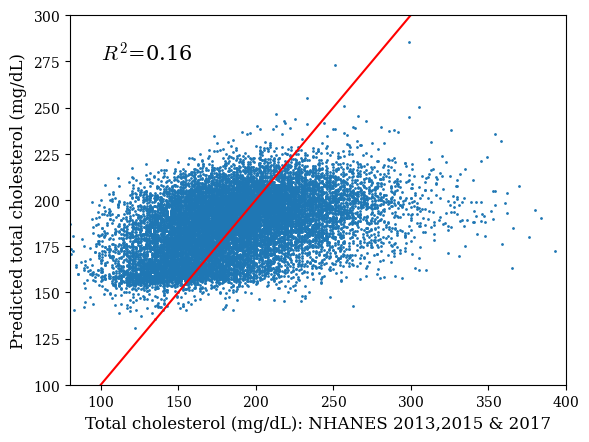

In [ ]:
param_dict = {'_a0_': 223.4927261651891, '_a2_': -0.04772252941823241, '_a3_': 0.003530771222274162, '_a4_': 0.7812353533617145, '_a6_': -123.22742926107325, '_a7_': 0.3074458699059204, '_a8_': 4.746767069661503, '_a10_': 0.03664316331593398, '_a12_': -0.0009930000749283358}
chol_model = Model_params(data = param_dict)

_a0_ = chol_model.a0
_a2_ = chol_model.a2
_a3_ = chol_model.a3
_a4_ = chol_model.a4
_a6_ = chol_model.a6
_a7_ = chol_model.a7
_a8_ = chol_model.a8
_a10_ = chol_model.a10
_a12_ = chol_model.a12

X['chol_pred'] =  ((((((_a12_ + ((_a7_ ** Sex) + _a10_)) * (((medication_high_BP + (Diabetes ** _a3_)) / _a2_) * _a7_)) + _a0_) / Age) ** (_a4_ + ((Age * _a10_) * ((_a3_ * (medication_high_BP + SBP)) ** (_a12_ * (_a6_ + HDL_Cholesterol)))))) * _a8_)

x = X['Total Cholesterol']
y = X['chol_pred']


r2_value = R2(target=x, predictions=y)

mape = np.mean(np.abs((x - y) / np.abs(x)))
mae = np.mean(np.abs(x - y))
rmse = np.mean((x - y)**2)**0.5
print(f'R2 value: {r2_value}')
print('Mean Absolute Error (MAE):', round(mae, 2))
print(f'Mean Absolute Percentage Error (MAPE): MAPE={np.round(mape*100, 1)}')
print('Root Mean Squared Error (RMSE):', round(rmse, 2))

X_line = np.linspace(10, 300)
plt.plot(X_line, X_line, c='r')

plt.xlim(80, 400)
plt.ylim(100, 300)

plt.scatter(x,y, s=1)
plt.text(100, 275, f"$R^{2}$={np.round(r2_value, 2)}", fontsize=15)

plt.ylabel('Predicted total cholesterol (mg/dL)', fontsize=12)
plt.xlabel('Total cholesterol (mg/dL): NHANES 2013,2015 & 2017', fontsize=12)

plt.show()




In [ ]:
param_dict = {'a0': 223.4927261651891,
              'a2': -0.04772252941823241,
              'a3': 0.003530771222274162,
              'a4': 0.7812353533617145,
              'a6': -123.22742926107325,
              'a7': 0.3074458699059204,
              'a8': 4.746767069661503,
              'a10': 0.03664316331593398,
              'a12': -0.0009930000749283358}
model = Model_params(data = param_dict)

scale_params = {'a0': 1e2, 'a2': 1e-2, 'a3': 1e-3, 'a4': 1e-1, 'a6': 1e2, 'a7': 1e-1, 'a8': 1, 'a10': 1e-2, 'a12': 1e-4}

Sex = df_no_nan['Sex'].values
Age = df_no_nan['Age'].values
medication_high_BP = df_no_nan['medication_high_BP'].values
Diabetes = df_no_nan['Diabetes'].values
SBP = df_no_nan['SBP'].values
HDL_Cholesterol = df_no_nan['HDL Cholesterol'].values

pymc_var = {}

with pm.Model() as model:

    # 2. Loop through parameters and set Sign-Constrained Priors
    for name, init_val in param_dict.items():
        scale = scale_params[name]
        mu_scaled = init_val / scale

        if init_val > 0:
            # If positive, it can range from 0 to Infinity
            bound_args = {'lower': 0}
        else:
            # If negative, it can range from -Infinity to 0
            bound_args = {'upper': 0}

        # Create a Truncated Normal distribution
        scaled_var = pm.TruncatedNormal(
            f"{name}_scaled",
            mu=mu_scaled,
            sigma=np.abs(mu_scaled * 0.2),
            **bound_args
        )

        pymc_var[name] = pm.Deterministic(name, scaled_var * scale)

    # 3. Define the Error Term (Observed noise). Standard deviation in total chol is ~40mg/dL
    sigma = pm.HalfNormal('sigma', sigma=40)

    mu =  ((((((pymc_var['a12'] + ((pymc_var['a7'] ** Sex) + pymc_var['a10'])) * (((medication_high_BP + (Diabetes ** pymc_var['a3'])) / pymc_var['a2']) * pymc_var['a7'])) + pymc_var['a0']) / Age) ** (pymc_var['a4'] + ((Age * pymc_var['a10']) * ((pymc_var['a3'] * (medication_high_BP + SBP)) ** (pymc_var['a12'] * (pymc_var['a6'] + HDL_Cholesterol)))))) * pymc_var['a8'])

    # Ensure the data used to fir the parameters corresponds to that with no missing HDL choleterol levels
    y_obs = df_no_nan['Total Cholesterol']

    # 5. Define the likelihood
    likelihood = pm.Normal(
        'obs',
        mu=mu,
        sigma=sigma,  # Your sigma=20
        observed=y_obs
    )

    # 6. run teh sampling
    print(f"Starting the sampling")
    trace = pm.sample(1000, tune=1000, chains=2, cores=2, progressbar=True)

    print(pm.summary(trace))

/usr/local/lib/python3.10/dist-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


          mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
a0     225.363  2.650  222.127  229.968      1.691    1.376       3.0   
a2      -0.046  0.005   -0.057   -0.037      0.001    0.001      36.0   
a3       0.004  0.000    0.003    0.004      0.000    0.000       3.0   
a4       0.789  0.009    0.779    0.804      0.005    0.004       3.0   
a6    -125.715  5.881 -137.226 -114.640      2.404    1.790       6.0   
a7       0.303  0.032    0.245    0.372      0.007    0.005      28.0   
a8       4.724  0.098    4.551    4.851      0.057    0.045       3.0   
a10      0.036  0.000    0.036    0.037      0.000    0.000       2.0   
a12     -0.001  0.000   -0.001   -0.001      0.000    0.000       4.0   
sigma   36.967  0.192   36.648   37.327      0.018    0.012     125.0   

       ess_tail  r_hat  
a0         56.0   1.90  
a2         48.0   1.44  
a3         21.0   2.59  
a4          2.0   2.13  
a6         17.0   1.30  
a7         26.0   1.30  
a8         17.0   1.8

In [ ]:
az.to_netcdf(trace, 'totchol_nhanes_posterior_060326.nc')

In [ ]:
trace = az.from_netcdf('data/posterior_samples/totchol_nhanes_posterior_060326.nc')

In [ ]:
param_list = list(i for i in trace.posterior.data_vars.keys() if not i.endswith('_scaled'))

/usr/local/lib/python3.12/dist-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


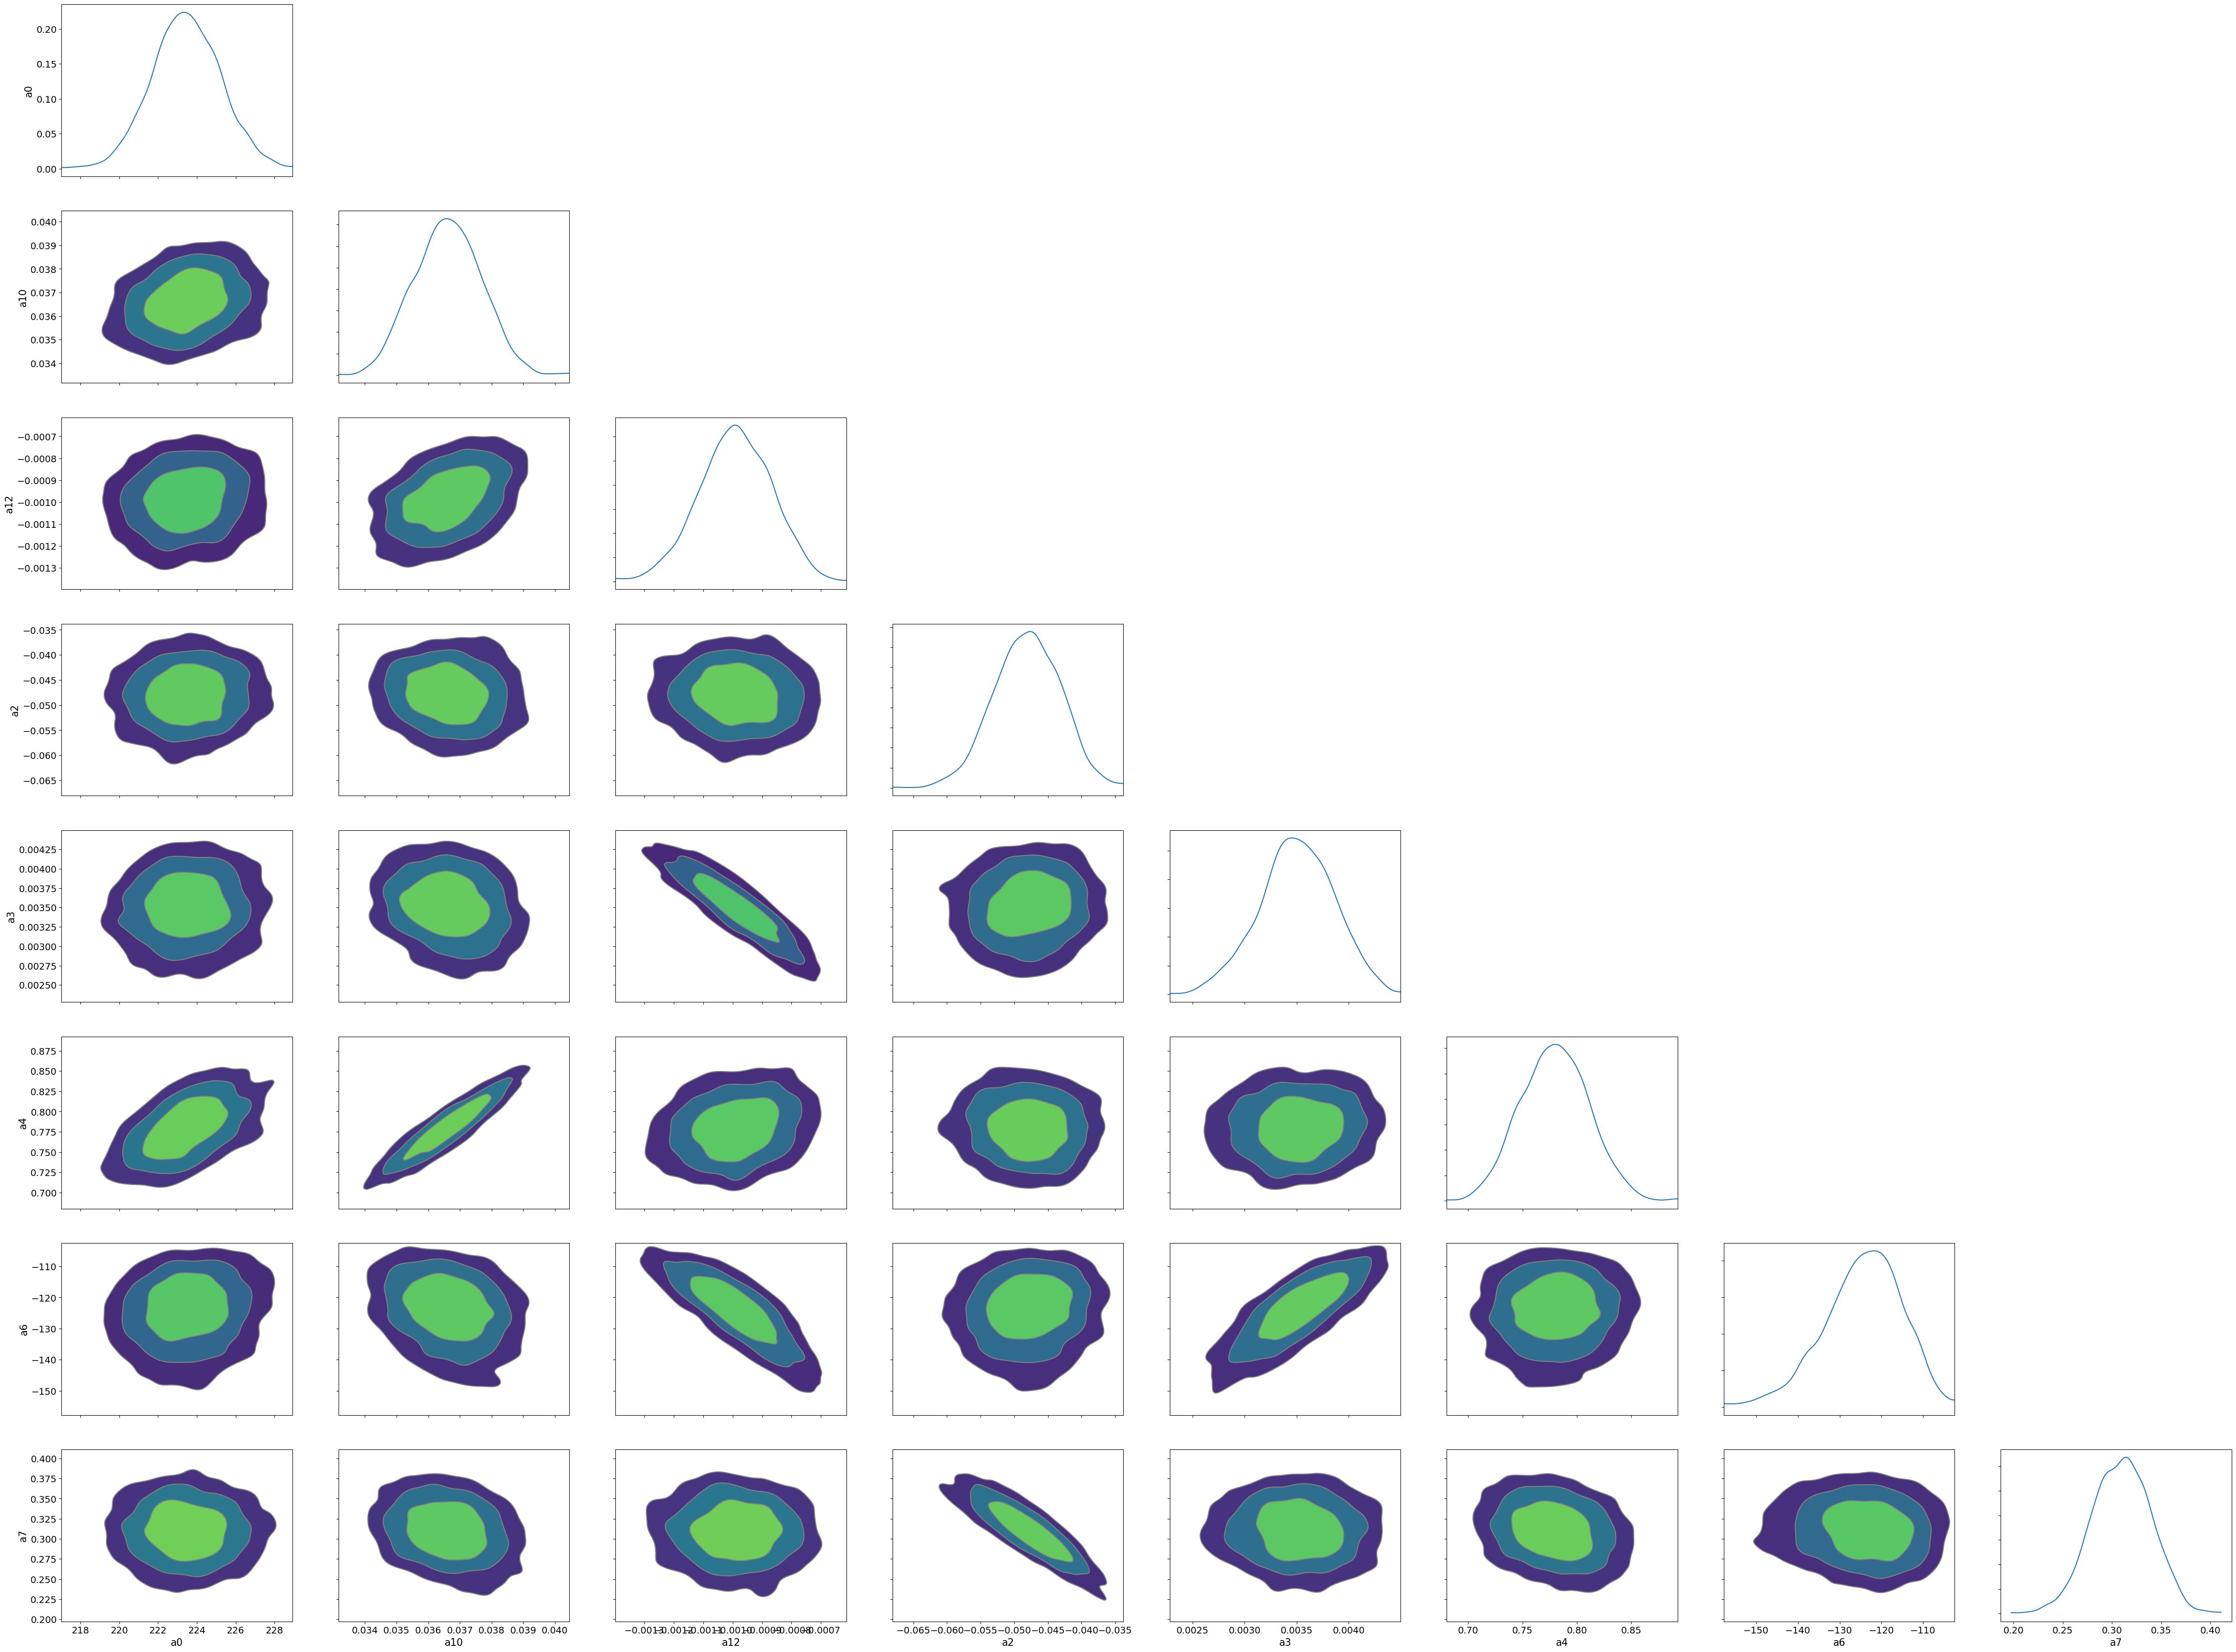

In [ ]:
## Check teh posterior parameter distributions
az.plot_pair(
    trace,
    var_names=param_list,
    kind='kde',
    marginals=True,
)
plt.show()

In [ ]:
X_oos = df_oos[['Sex', 'Age', 'Weight', 'Height', 'BMI' , 'Smoker', 'Total Cholesterol' ,'medication_high_bp', 'HDL Cholesterol', 'SBP',  'Diabetes']]

In [ ]:
len(df_oos)

5720

/tmp/ipykernel_1539/3625494375.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_oos['chol_pred'] =  ((((((_a12_ + ((_a7_ ** Sex) + _a10_)) * (((medication_high_BP + (Diabetes ** _a3_)) / _a2_) * _a7_)) + _a0_) / Age) ** (_a4_ + ((Age * _a10_) * ((_a3_ * (medication_high_BP + SBP)) ** (_a12_ * (_a6_ + HDL_Cholesterol)))))) * _a8_)


R2 value: 0.17557602991780674
Mean Absolute Error (MAE): 29.72
Mean Absolute Percentage Error (MAPE): MAPE=16.8
Root Mean Squared Error (RMSE): 38.76


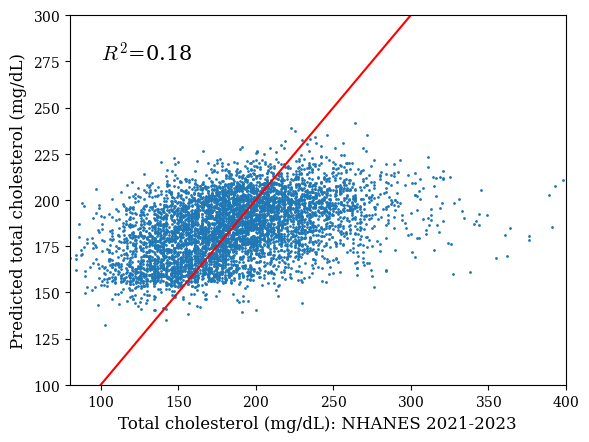

In [ ]:
############ Test on the out of sample data ###############

Age = X_oos['Age'].values
Sex = X_oos['Sex'].values
medication_high_BP = X_oos['medication_high_bp'].values
Diabetes = X_oos['Diabetes'].values
HDL_Cholesterol = X_oos['HDL Cholesterol'].values
SBP = X_oos['SBP'].values

param_dict = {'_a0_': 223.4927261651891, '_a2_': -0.04772252941823241, '_a3_': 0.003530771222274162, '_a4_': 0.7812353533617145, '_a6_': -123.22742926107325, '_a7_': 0.3074458699059204, '_a8_': 4.746767069661503, '_a10_': 0.03664316331593398, '_a12_': -0.0009930000749283358}
chol_model = Model_params(data = param_dict)

_a0_ = chol_model.a0
_a2_ = chol_model.a2
_a3_ = chol_model.a3
_a4_ = chol_model.a4
_a6_ = chol_model.a6
_a7_ = chol_model.a7
_a8_ = chol_model.a8
_a10_ = chol_model.a10
_a12_ = chol_model.a12

X_oos['chol_pred'] =  ((((((_a12_ + ((_a7_ ** Sex) + _a10_)) * (((medication_high_BP + (Diabetes ** _a3_)) / _a2_) * _a7_)) + _a0_) / Age) ** (_a4_ + ((Age * _a10_) * ((_a3_ * (medication_high_BP + SBP)) ** (_a12_ * (_a6_ + HDL_Cholesterol)))))) * _a8_)

x = X_oos['Total Cholesterol']
y = X_oos['chol_pred']


r2_value = R2(target=x, predictions=y)

mape = np.mean(np.abs((x - y) / np.abs(x)))
mae = np.mean(np.abs(x - y))
rmse = np.mean((x - y)**2)**0.5
print(f'R2 value: {r2_value}')
print('Mean Absolute Error (MAE):', round(mae, 2))
print(f'Mean Absolute Percentage Error (MAPE): MAPE={np.round(mape*100, 1)}')
print('Root Mean Squared Error (RMSE):', round(rmse, 2))

X_line = np.linspace(10, 300)
plt.plot(X_line, X_line, c='r')

plt.xlim(80, 400)
plt.ylim(100, 300)

plt.scatter(x,y, s=1)
plt.text(100, 275, f"$R^{2}$={np.round(r2_value, 2)}", fontsize=15)

plt.ylabel('Predicted total cholesterol (mg/dL)', fontsize=12)
plt.xlabel('Total cholesterol (mg/dL): NHANES 2021-2023', fontsize=12)

plt.show()


## HDL cholesterol

In [ ]:
df_test = pd.read_parquet('../chol_BP_training_data.parquet')
X = df_test[['Sex', 'Age', 'Weight', 'Height', 'BMI' , 'Smoker', 'Total Cholesterol',"Chol_medication" ,'medication_high_BP', 'HDL Cholesterol', 'SBP',  'Diabetes']]

In [ ]:
X = df_oos[['Sex', 'Age', 'Weight', 'Height', 'BMI' , 'Smoker', 'Total Cholesterol','HDL Cholesterol', 'SBP',  'Diabetes']]

In [ ]:
df_test[['Sex', 'Age', 'BMI', "Diabetes", 'Smoker']]

,Sex,Age,BMI,Diabetes,Smoker
SEQN,,,,,
93707.0,0.0,13.0,18.094455,0.0,0.0
93709.0,1.0,75.0,38.894128,0.0,1.0
93711.0,0.0,56.0,21.337009,0.0,0.0
93712.0,0.0,18.0,19.725491,0.0,1.0
93713.0,0.0,67.0,23.481125,0.0,1.0
...,...,...,...,...,...
83720.0,0.0,36.0,23.942856,0.0,0.0
83721.0,0.0,52.0,25.606801,0.0,0.0
83724.0,0.0,80.0,24.890238,0.0,0.0


In [ ]:
df_oos[['Sex', 'Age', 'BMI', "Diabetes", 'Smoker']]

,Sex,Age,BMI,Diabetes,Smoker
0,0.0,43.0,26.970616,0.0,0.0
1,0.0,66.0,33.546829,0.0,0.0
2,0.0,44.0,29.685509,1.0,0.0
5,0.0,34.0,30.166927,0.0,0.0
6,0.0,68.0,42.584163,0.0,0.0
...,...,...,...,...,...
8494,0.0,70.0,21.393860,0.0,0.0
8495,0.0,69.0,27.934901,1.0,0.0
8496,0.0,76.0,26.350277,0.0,0.0
8499,0.0,40.0,25.532464,0.0,0.0


In [ ]:
X = df_oos.copy()
X = X[~X['HDL Cholesterol'].isnull()]
X = X[~X['BMI'].isnull()]

In [ ]:



BMI = X['BMI']
Diabetes = X['Diabetes']
HDL_Cholesterol = X['HDL Cholesterol']
Age = X['Age']
Sex = X['Sex']

In [ ]:
X

,Sex,Age,Weight,Height,BMI,Smoker,Total Cholesterol,Chol_medication,medication_high_BP,HDL Cholesterol,SBP,Diabetes
SEQN,,,,,,,,,,,,
93707.0,0.0,13.0,45.4,158.4,18.094455,0.0,189.0,0.0,0.0,68.0,128.0,0.0
93709.0,1.0,75.0,88.8,151.1,38.894128,1.0,176.0,0.0,1.0,65.0,120.0,0.0
93711.0,0.0,56.0,62.1,170.6,21.337009,0.0,238.0,1.0,0.0,72.0,108.0,0.0
93712.0,0.0,18.0,58.9,172.8,19.725491,1.0,182.0,0.0,0.0,48.0,112.0,0.0
93713.0,0.0,67.0,74.9,178.6,23.481125,1.0,184.0,0.0,0.0,48.0,104.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
83720.0,0.0,36.0,89.0,192.8,23.942856,0.0,202.0,0.0,0.0,74.0,130.0,0.0
83721.0,0.0,52.0,79.5,176.2,25.606801,0.0,138.0,1.0,0.0,55.0,108.0,0.0
83724.0,0.0,80.0,77.1,176.0,24.890238,0.0,157.0,0.0,1.0,51.0,164.0,0.0


In [ ]:
X['HDL Cholesterol']

,HDL Cholesterol
0,45.0
1,60.0
2,49.0
5,46.0
6,42.0
...,...
8494,60.0
8495,34.0
8496,51.0
8499,54.0


/tmp/ipykernel_1539/2732924809.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['HDL_chol_pred'] = (((((((_a2_ ** (np.exp(BMI) ** _a12_)) / -(_a0_)) * (-(_a0_) ** Sex)) + (_a4_ ** Age)) * _a2_) ** ((_a8_ ** Diabetes) * _a12_)) + -((_a5_ + Smoker)))


R2 value: 1.0
Mean Absolute Percentage Error (MAPE): nan
Accuracy: nan


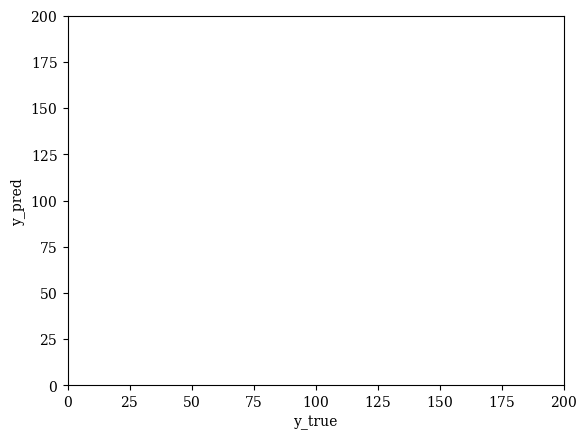

In [ ]:
param_dict = {'_a0_': 0.4869194798791581, '_a2_': 8.116649973043269e-15, '_a4_': 0.9802926681647043, '_a5_': 74.67368245639754, '_a8_': 0.9926383777067802, '_a12_': -0.15064679894785266}

chol_model = Model_params(data = param_dict)

_a0_ = chol_model.a0
_a2_ = chol_model.a2
_a4_ = chol_model.a4
_a5_ = chol_model.a5
_a8_ = chol_model.a8
_a12_ = chol_model.a12


X['HDL_chol_pred'] = (((((((_a2_ ** (np.exp(BMI) ** _a12_)) / -(_a0_)) * (-(_a0_) ** Sex)) + (_a4_ ** Age)) * _a2_) ** ((_a8_ ** Diabetes) * _a12_)) + -((_a5_ + Smoker)))

y_target = X['HDL Cholesterol']
y_pred = X['HDL_chol_pred']

r2 = R2(target=y_target, predictions=y_pred )
mape = np.mean(np.abs((y_target - y_pred) / np.abs(y_target)))

print(f'R2 value: {r2}')
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Accuracy:', round(100*(1 - mape), 2))

plt.scatter( x = y_target, y = y_pred, s=1)
plt.xlim(0, 200)
plt.ylim(0,200)
plt.xlabel('y_true')
plt.ylabel('y_pred')

plt.show()

In [ ]:
# Detailed inspection of the values causing the final NaN
print(f"Term C min/max: {term_c.min()}, {term_c.max()}")
print(f"Final Exponent min/max: {final_exponent.min()}, {final_exponent.max()}")

# Check if we are raising very small numbers to very large negative powers
test_power = np.abs(term_c) ** final_exponent
print(f"Number of Infs in final power: {np.isinf(test_power).sum()}")
print(f"Number of NaNs in final power: {np.isnan(test_power).sum()}")

# Look at the first few values specifically
df_check = pd.DataFrame({
    'abs_term_c': np.abs(term_c),
    'final_exponent': final_exponent,
    'result': test_power
})
print("\nFirst 5 rows of final calculation:")
display(df_check.head())

Term C min/max: -1.4818206541262835e-14, 5.242295822071774e-15
Final Exponent min/max: -0.15064679894785266, -0.14953779411431595
Number of Infs in final power: 0
Number of NaNs in final power: 0

First 5 rows of final calculation:


,abs_term_c,final_exponent,result
0,6.092444e-15,-0.150647,138.508252
1,1.136813e-14,-0.150647,126.085696
2,8.125703e-15,-0.149538,127.940579
5,7.683389e-15,-0.150647,133.750768
6,1.371052e-14,-0.150647,122.576848


In [ ]:
print(f"Data types in X:\n{X[['Sex', 'BMI', 'Age', 'Diabetes', 'Smoker']].dtypes}")

# Diagnostic: Check the specific term causing NaNs
base = -_a0_
print(f"\nBase value (-(_a0_)): {base}")

# Check if Sex or the outer exponent term contains non-integers in df_oos
term1 = (base ** X['Sex'])
outer_exponent = (_a8_ ** X['Diabetes']) * _a12_

print(f"NaNs in (base ** Sex): {term1.isna().sum()}")
print(f"NaNs in outer exponent: {outer_exponent.isna().sum()}")

# Show a few rows of the components
diagnostic_df = pd.DataFrame({
    'Sex': X['Sex'],
    'Sex_is_int': X['Sex'].apply(lambda x: float(x).is_integer()),
    'Term1': term1,
    'Outer_Exp': outer_exponent
})
display(diagnostic_df.head())

Data types in X:
Sex         float64
BMI         float64
Age         float64
Diabetes    float64
Smoker      float64
dtype: object

Base value (-(_a0_)): -0.4869194798791581
NaNs in (base ** Sex): 0
NaNs in outer exponent: 0


,Sex,Sex_is_int,Term1,Outer_Exp
0,0.0,True,1.0,-0.150647
1,0.0,True,1.0,-0.150647
2,0.0,True,1.0,-0.149538
5,0.0,True,1.0,-0.150647
6,0.0,True,1.0,-0.150647


In [ ]:
## run the MCMC to find the joint posterior of the parameters ##

{'_a0_': 0.4869194798791581, '_a2_': 8.116649973043269e-15, '_a4_': 0.9802926681647043, '_a5_': 74.67368245639754, '_a8_': 0.9926383777067802, '_a12_': -0.15064679894785266}

pymc_var = {}

with pm.Model() as model:
  for param_name, value in chol_model.__dict__.items():
    if param_name in {'a0', 'a2','a4' ,'a8', 'a12'}:
      pymc_var[param_name] = pm.Normal(param_name, mu=value, sigma=2)
    elif param_name in {'a5'}:
      pymc_var[param_name] = pm.Normal(param_name, mu=value, sigma=np.abs(0.2*value))
    else:
      raise ValueError('Missed a variable')

  sigma = pm.HalfNormal('sigma', sigma=1)

  mu = (((((((pymc_var['a2'] ** (np.exp(np.array(BMI)) ** pymc_var['a12'])) / -(pymc_var['a0'])) * (-(pymc_var['a0']) ** np.array(Sex))) + (pymc_var['a4'] ** np.array(Age))) * pymc_var['a2']) ** ((pymc_var['a8'] ** np.array(Diabetes)) * pymc_var['a12'])) + -((pymc_var['a5'] + np.array(Smoker))))
  y_obs = X['HDL Cholesterol']

  likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y_obs)
  step = pm.Metropolis()

  trace = pm.sample(5000, tune=1000, step=step, chains = 5, progressbar=True)
  print(pm.summary(trace))

/usr/local/lib/python3.10/dist-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a0      0.469  0.010   0.449    0.487      0.003    0.002      11.0      16.0   
a2      0.000  0.000   0.000    0.000      0.000    0.000   25000.0   25000.0   
a4      0.981  0.001   0.979    0.983      0.000    0.000       6.0       6.0   
a5     74.712  1.000  73.498   77.036      0.401    0.298       6.0      19.0   
a8      0.993  0.000   0.992    0.993      0.000    0.000      14.0      27.0   
a12    -0.151  0.000  -0.151   -0.151      0.000    0.000       6.0      30.0   
sigma  14.268  0.081  14.130   14.425      0.008    0.005     111.0      85.0   

       r_hat  
a0      1.42  
a2       NaN  
a4      2.50  
a5      2.37  
a8      1.55  
a12     3.07  
sigma   1.07  


In [ ]:
trace.posterior.keys().tolist()

In [ ]:
az.to_netcdf(trace, data_path / 'posterior_samples/hdl_chol_posterior.nc')

'hdl_chol_posterior.nc'

## Systolic blood pressure

In [ ]:
!pwd

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


In [ ]:
df_no_nan = pd.read_parquet(data_path / 'sbp_mSHIFT_SHeS_training_data.parquet')

In [ ]:
Age = df_no_nan['Age'].values
CVD = df_no_nan['CVD'].values
Sex = df_no_nan['Sex'].values
BMI = df_no_nan['BMI'].values
Weight = df_no_nan['Weight'].values
high_bp_diagnosis = df_no_nan['high_bp_diagnosis'].values
Weight = df_no_nan['Weight'].values
Height = df_no_nan['Height'].values

X = df_no_nan.copy()

In [ ]:
X

,Sex,Age,Diabetes,CVD,Height,Weight,BMI,Smoker,SBP,medication_high_BP,parental_diabetes,high_bp_diagnosis,SBP_pred
SEQN,,,,,,,,,,,,,
93705.0,1.0,66.0,0.0,0,158.3,79.5,31.725268,0.0,200.000000,1.0,1.0,1.0,136.200745
93706.0,0.0,18.0,0.0,0,175.7,66.3,21.476821,0.0,111.333333,0.0,0.0,0.0,109.488702
93708.0,1.0,66.0,0.0,0,150.2,53.5,23.714497,0.0,142.000000,1.0,1.0,1.0,134.390746
93709.0,1.0,75.0,0.0,1,151.1,88.8,38.894128,1.0,118.666667,1.0,1.0,1.0,140.798648
93711.0,0.0,56.0,0.0,0,170.6,62.1,21.337009,0.0,101.333333,0.0,0.0,0.0,122.848454
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83721.0,0.0,52.0,0.0,0,176.2,79.5,25.606801,0.0,109.333333,0.0,0.0,0.0,122.491280
83723.0,0.0,61.0,1.0,0,173.5,99.5,33.054008,0.0,139.333333,0.0,0.0,0.0,127.658689
83724.0,0.0,80.0,0.0,0,176.0,77.1,24.890238,0.0,166.666667,1.0,0.0,1.0,142.283111


R2 value: 0.2974009072816629
Mean Absolute Error (MAE): 11.54
Mean Absolute Percentage Error (MAPE): 9.23
Root Mean Squared Error (RMSE): 15.55


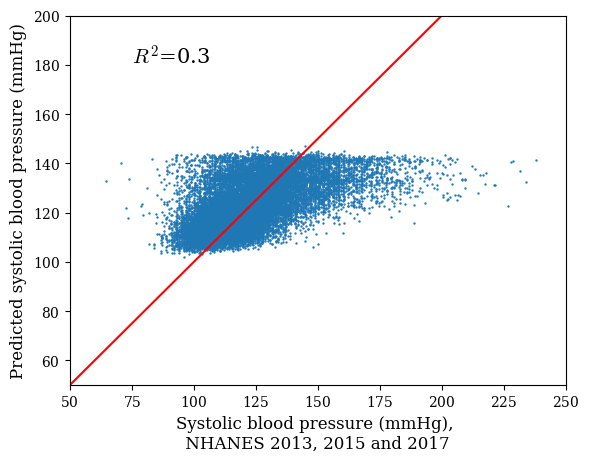

In [ ]:
param_dict =  {'_a1_': 67.93919539805724, '_a2_': -0.9338584107582357, '_a5_': 1.8776995537206418, '_a6_': -0.05943302409493654, '_a7_': 0.0632866878860326,
               '_a0_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a8_': 1.0, '_a9_': 1.0, '_a10_': 1.0}

model = Model_params(data = param_dict)

_a0_ = model.a0
_a1_ = model.a1
_a2_= model.a2
_a3_ = model.a3
_a5_ = model.a5
_a6_ = model.a6
_a7_ = model.a7
_a8_ = model.a8
_a9_ = model.a9
_a10_ = model.a10
_a1_ = model.a1
_a2_ = model.a2

X['SBP_pred'] =  np.exp((((((Weight / (_a2_ + (_a5_ * Age))) + _a1_) + np.sqrt(Age)) * _a7_) + (-(high_bp_diagnosis) * _a6_)))

y = X['SBP_pred']
x = X['SBP']

X_line = np.linspace(50, 250)
plt.plot(X_line, X_line, c='r')

plt.xlim(50, 250)
plt.ylim(50, 200)

r2_value = R2(x, y)
mape = np.mean(np.abs((x - y) / np.abs(x)))
mae = np.mean(np.abs(x - y))
rmse = np.mean((x - y)**2)**0.5

print(f'R2 value: {r2_value}')
print('Mean Absolute Error (MAE):', round(mae, 2))
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Root Mean Squared Error (RMSE):', round(rmse, 2))

plt.scatter(x,y, s=0.5)
plt.text(75, 180, f"$R^{2}$={np.round(r2_value, 2)}", fontsize=15)
#plt.text(75, 170, f"MAPE={np.round(mape*100, 1)}%", fontsize=15)
plt.ylabel('Predicted systolic blood pressure (mmHg)', fontsize=12)
plt.xlabel('Systolic blood pressure (mmHg), \n NHANES 2013, 2015 and 2017 ', fontsize=12)
plt.title('')
#plt.savefig('results/Plots/imputation_models/sbp_nhanes_train.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
Age = df_oos['Age'].values
Weight = df_oos['Weight'].values
high_bp_diagnosis = df_oos['high_bp_diagnosis'].values


X_oos = df_oos.copy()

In [ ]:
X_oos = df_oos[~df_oos['SBP'].isnull()]

Age = X_oos['Age'].values
Weight = X_oos['Weight'].values
high_bp_diagnosis = X_oos['high_bp_diagnosis'].values

In [ ]:
len(X_oos)

6391

/tmp/ipykernel_1539/1072132537.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_oos['SBP_pred'] =  np.exp((((((Weight / (_a2_ + (_a5_ * Age))) + _a1_) + np.sqrt(Age)) * _a7_) + (-(high_bp_diagnosis) * _a6_)))


R2 value: 0.17300028217547025
Mean Absolute Error (MAE): 12.57
Mean Absolute Percentage Error (MAPE): 10.62
Root Mean Squared Error (RMSE): 16.4


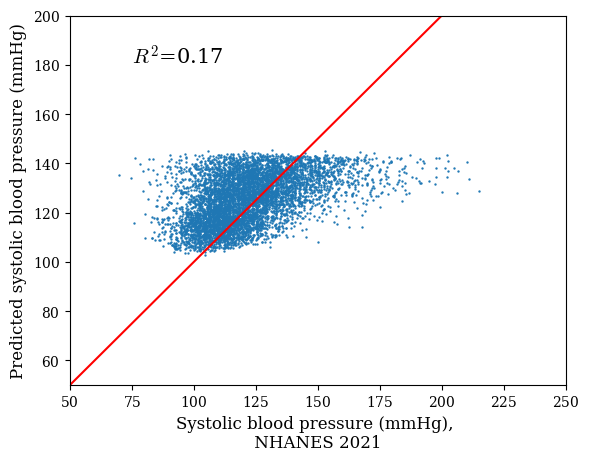

In [ ]:
param_dict =  {'_a1_': 67.93919539805724, '_a2_': -0.9338584107582357, '_a5_': 1.8776995537206418, '_a6_': -0.05943302409493654, '_a7_': 0.0632866878860326,
               '_a0_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a8_': 1.0, '_a9_': 1.0, '_a10_': 1.0}

model = Model_params(data = param_dict)

_a0_ = model.a0
_a1_ = model.a1
_a2_= model.a2
_a3_ = model.a3
_a5_ = model.a5
_a6_ = model.a6
_a7_ = model.a7
_a8_ = model.a8
_a9_ = model.a9
_a10_ = model.a10
_a1_ = model.a1
_a2_ = model.a2

X_oos['SBP_pred'] =  np.exp((((((Weight / (_a2_ + (_a5_ * Age))) + _a1_) + np.sqrt(Age)) * _a7_) + (-(high_bp_diagnosis) * _a6_)))

y = X_oos['SBP_pred']
x = X_oos['SBP']

X_line = np.linspace(50, 250)
plt.plot(X_line, X_line, c='r')

plt.xlim(50, 250)
plt.ylim(50, 200)

r2_value = R2(x, y)
mape = np.mean(np.abs((x - y) / np.abs(x)))
mae = np.mean(np.abs(x - y))
rmse = np.mean((x - y)**2)**0.5

print(f'R2 value: {r2_value}')
print('Mean Absolute Error (MAE):', round(mae, 2))
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Root Mean Squared Error (RMSE):', round(rmse, 2))

plt.scatter(x,y, s=0.5)
plt.text(75, 180, f"$R^{2}$={np.round(r2_value, 2)}", fontsize=15)
#plt.text(75, 170, f"MAPE={np.round(mape*100, 1)}%", fontsize=15)
plt.ylabel('Predicted systolic blood pressure (mmHg)', fontsize=12)
plt.xlabel('Systolic blood pressure (mmHg), \n NHANES 2021 ', fontsize=12)
plt.title('')
plt.savefig('results/Plots/imputation_models/sbp_nhanes_train_oos.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## run the MCMC to find the joint posterior of the parameters ##
param_dict =  {'a1': 67.93919539805724, 'a2': -0.9338584107582357, 'a5': 1.8776995537206418, 'a6': -0.05943302409493654, 'a7': 0.0632866878860326}
scale_params = {'a1': 1e1, 'a2': 1e-1, 'a5': 1e0, 'a6': 1e-2, 'a7': 1e-2}

model = Model_params(data = param_dict)
pymc_var = {}

with pm.Model() as model:

    # 2. Loop through parameters and set Sign-Constrained Priors
    for name, init_val in param_dict.items():
        scale = scale_params[name]
        mu_scaled = init_val / scale

        # Determine bounds based on the sign of the initial value
        if init_val > 0:
            # If positive, it can range from 0 to Infinity
            bound_args = {'lower': 0}
        else:
            # If negative, it can range from -Infinity to 0
            bound_args = {'upper': 0}

        # Create a Truncated Normal distribution
        # but the bounds ensure it never crosses zero.
        scaled_var = pm.TruncatedNormal(
            f"{name}_scaled",
            mu=mu_scaled,
            sigma=np.abs(mu_scaled * 0.2),
            **bound_args
        )

        pymc_var[name] = pm.Deterministic(name, scaled_var * scale)

    # 3. Define the Error Term (Observed noise). Standard deviation in SBP chol is ~20mmHg
    sigma = pm.HalfNormal('sigma', sigma=20)

    mu = pm.math.exp((((((Weight / (pymc_var['a2'] + (pymc_var['a5'] * Age))) + pymc_var['a1']) + pm.math.sqrt(Age)) * pymc_var['a7']) + (-(high_bp_diagnosis) * pymc_var['a6'])))

    # Ensure the data used to fir the parameters corresponds to that with no missing HDL choleterol levels
    y_obs = df_no_nan['SBP']

    likelihood = pm.Normal(
        'obs',
        mu=mu,
        sigma=sigma,
        observed=y_obs
    )

    # 6. Sampling
    print(f"Starting the sampling")
    trace = pm.sample(1000, tune=1000, chains=2, cores=2, progressbar=True)

    print(pm.summary(trace))

/usr/local/lib/python3.10/dist-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


            mean       sd     hdi_3%    hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
a0         0.413    0.005      0.410      0.424      0.002    0.001       6.0   
a3     10598.705  429.744  10315.233  11606.343    179.663  134.147       6.0   
a7         0.001    0.000      0.001      0.001      0.000    0.000       5.0   
a8       -18.516    1.157    -20.813    -16.430      0.331    0.243      13.0   
a9     63824.680  266.343  63161.486  64318.258     47.440   33.860      22.0   
sigma     11.006    0.072     10.883     11.134      0.005    0.004     188.0   

       ess_tail  r_hat  
a0         10.0   2.86  
a3         19.0   2.44  
a7          5.0   4.69  
a8         35.0   1.29  
a9         13.0   1.70  
sigma     113.0   1.03  


In [ ]:
az.to_netcdf(trace, 'sbp_posterior_nhanes_08032926.nc')

# Weight

In [ ]:
df = pd.read_parquet('data/df_SHeS_unimputed.parquet')
X = df[~df['weight'].isnull()]

In [ ]:
len(X)

3151

In [ ]:
Sex = X['Sex']
age = X['age']
BMI = X['BMI']
Taking_BPM = X['Taking BPM']
white_OB = X['white_OB']

/tmp/ipykernel_164/1926547230.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['weight_pred'] = 64.5961 - 5.9513 * Sex + 0.9525 *age - 0.1290 * (Sex * age) - 0.0097 * age**2 + 6.8561*Taking_BPM


R2 value: 0.19064526171105778
Mean Absolute Percentage Error (MAPE): 15.59
Accuracy: 84.41


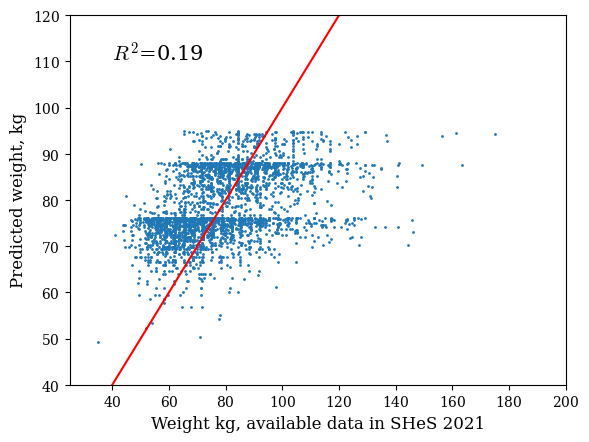

In [ ]:
param_dict =  {'_a2_': 46.149164212739805, '_a3_': -144.44811827422785, '_a5_': 13.308135888474924, '_a8_': 6.856146177587821, '_a11_': -0.0014133525944102084,
               '_a0_': 1.0, '_a1_': 1.0, '_a4_': 1.0, '_a6_': 1.0, '_a7_': 1.0, '_a9_': 1.0, '_a10_': 1.0, '_a12_': 1.0, '_a13_': 1.0, '_a14_': 1.0, '_a15_': 1.0}

model = Model_params(data = param_dict)

_a0_ = model.a0
_a1_ = model.a1
_a2_= model.a2
_a3_ = model.a3
_a5_ = model.a5
_a6_ = model.a6
_a7_ = model.a7
_a8_ = model.a8
_a9_ = model.a9
_a10_ = model.a10
_a11_ = model.a11
_a12_ = model.a12
_a1_ = model.a1
_a2_ = model.a2

#['weight_pred'] =  (((((((Sex * _a5_) + age) + _a3_) * (_a2_ + age)) * _a11_) + Taking_BPM) * _a8_)
X['weight_pred'] = 64.5961 - 5.9513 * Sex + 0.9525 *age - 0.1290 * (Sex * age) - 0.0097 * age**2 + 6.8561*Taking_BPM

y_target = X['weight']
y_pred = X['weight_pred']

r2 = R2(target=y_target, predictions=y_pred )
mape = np.mean(np.abs((y_target - y_pred) / np.abs(y_target)))

print(f'R2 value: {r2}')
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Accuracy:', round(100*(1 - mape), 2))

plt.scatter( x = y_target, y = y_pred, s=1)
X_line = np.linspace(20, 250)
plt.plot(X_line, X_line, c='r')

plt.text(40, 110, f"$R^{2}$={np.round(r2, 2)}", fontsize=15)
plt.xlim(25, 200)
plt.ylim(40,120)
plt.xlabel('Weight kg, available data in SHeS 2021',  fontsize=12)
plt.ylabel('Predicted weight, kg', fontsize=12)
plt.savefig('results/Plots/imputation_models/weight_train.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_oos = pd.read_parquet('data/ndns_test_data.parquet')

# this variable was mistakenly labelled as high blood pressure when it in fact related to taking blood presssure medication
df_oos.rename(columns={'High BP': 'medication_high_bp'}, inplace=True)
X_oos = df_oos[~df_oos['weight'].isnull()]

In [ ]:
len(X_oos)

772

In [ ]:
Sex = X_oos['Sex']
age = X_oos['age']
Taking_BPM = X_oos['medication_high_bp']
white_OB = X_oos['white_OB']

R2 value: 0.1625009272454958
Mean Absolute Percentage Error (MAPE): 16.51
Accuracy: 83.49


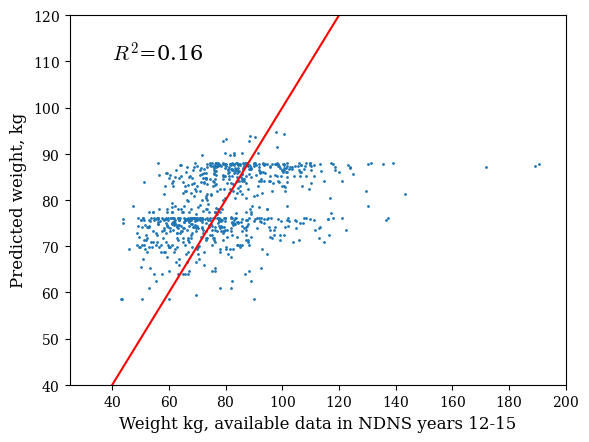

In [ ]:
param_dict =  {'_a2_': 46.149164212739805, '_a3_': -144.44811827422785, '_a5_': 13.308135888474924, '_a8_': 6.856146177587821, '_a11_': -0.0014133525944102084,
               '_a0_': 1.0, '_a1_': 1.0, '_a4_': 1.0, '_a6_': 1.0, '_a7_': 1.0, '_a9_': 1.0, '_a10_': 1.0, '_a12_': 1.0, '_a13_': 1.0, '_a14_': 1.0, '_a15_': 1.0}

model = Model_params(data = param_dict)

_a0_ = model.a0
_a1_ = model.a1
_a2_= model.a2
_a3_ = model.a3
_a5_ = model.a5
_a6_ = model.a6
_a7_ = model.a7
_a8_ = model.a8
_a9_ = model.a9
_a10_ = model.a10
_a11_ = model.a11
_a12_ = model.a12
_a1_ = model.a1
_a2_ = model.a2

X_oos['weight_pred'] =  (((((((Sex * _a5_) + age) + _a3_) * (_a2_ + age)) * _a11_) + Taking_BPM) * _a8_)

y_target = X_oos['weight']
y_pred = X_oos['weight_pred']

r2 = R2(target=y_target, predictions=y_pred )
mape = np.mean(np.abs((y_target - y_pred) / np.abs(y_target)))

print(f'R2 value: {r2}')
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Accuracy:', round(100*(1 - mape), 2))

plt.scatter( x = y_target, y = y_pred, s=1)
X_line = np.linspace(20, 250)
plt.plot(X_line, X_line, c='r')

plt.text(40, 110, f"$R^{2}$={np.round(r2, 2)}", fontsize=15)
plt.xlim(25, 200)
plt.ylim(40,120)
plt.xlabel('Weight kg, available data in NDNS years 12-15',  fontsize=12)
plt.ylabel('Predicted weight, kg', fontsize=12)
plt.savefig('results/Plots/imputation_models/weight_oos.png', dpi=300, bbox_inches='tight')
plt.show()

## Height


In [ ]:
param_dict =   {'_a5_': -13.957009489497386, '_a7_': 180.1502483791849, '_a9_': -0.0014516389387402634,
                '_a0_': 1.0, '_a1_': 1.0, '_a2_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a6_': 1.0, '_a8_': 1.0, '_a10_': 1.0, '_a11_': 1.0, '_a12_': 1.0, '_a13_': 1.0, '_a14_': 1.0, '_a15_': 1.0}

model = Model_params(data = param_dict)

_a0_ = model.a0
_a1_ = model.a1
_a2_= model.a2
_a3_ = model.a3
_a5_ = model.a5
_a6_ = model.a6
_a7_ = model.a7
_a8_ = model.a8
_a9_ = model.a9
_a10_ = model.a10
_a11_ = model.a11
_a12_ = model.a12
_a1_ = model.a1
_a2_ = model.a2

X['height_pred'] =  ((age * (age * _a9_)) + (((white_OB + _a5_) * Sex) + _a7_))

y_target = X['height']
y_pred = X['height_pred']

r2 = R2(target=y_target, predictions=y_pred )
mape = np.mean(np.abs((y_target - y_pred) / np.abs(y_target)))

print(f'R2 value: {r2}')
print('Mean Absolute Percentage Error (MAPE):', round(mape * 100, 2))
print('Accuracy:', round(100*(1 - mape), 2))

plt.scatter( x = y_target, y = y_pred, s=5)
plt.xlim(50, 200)
plt.ylim(50,200)
plt.xlabel('y_true')
plt.ylabel('y_pred')

plt.show()

In [ ]:
df_no_nan = df[~df['height'].isnull()]

In [ ]:
X = df_no_nan.copy()

Sex = X['Sex'].values
age = X['age'].values
BMI = X['BMI'].values
Taking_BPM = X['Taking BPM'].values
white_OB = X['white_OB'].values

In [ ]:
param_dict =   {'a5': -13.957009489497386, 'a7': 180.1502483791849, 'a9': -0.0014516389387402634}
scale_params = {'a5': 1e1, 'a7': 1e3, 'a9': 1e-3}

model = Model_params(data = param_dict)
pymc_var = {}

with pm.Model() as model:

    # Loop through parameters and set sign-constrained Priors
    for name, init_val in param_dict.items():
        scale = scale_params[name]
        mu_scaled = init_val / scale

        # Determine bounds based on the sign of the initial value
        if init_val > 0:
            # If positive, it can range from 0 to Infinity
            bound_args = {'lower': 0}
        else:
            # If negative, it can range from -Infinity to 0
            bound_args = {'upper': 0}

        # Create a Truncated Normal distribution for the likelihood
        # the bounds ensure it never crosses zero.
        scaled_var = pm.TruncatedNormal(
            f"{name}_scaled",
            mu=mu_scaled,
            sigma=np.abs(mu_scaled * 0.2),
            **bound_args
        )

        pymc_var[name] = pm.Deterministic(name, scaled_var * scale)

    #Define the error term, Standard deviation in hieght is ~10cm
    sigma = pm.HalfNormal('sigma', sigma=10)

    mu = ((age * (age * pymc_var['a9'])) + (((white_OB + pymc_var['a5']) * Sex) + pymc_var['a7']))

    # Ensure the data used to fir the parameters corresponds to that with no missing HDL choleterol levels
    y_obs = df_no_nan['height']

    likelihood = pm.Normal(
        'obs',
        mu=mu,
        sigma=sigma,
        observed=y_obs
    )

    # Sampling
    print(f"Starting the sampling")
    trace = pm.sample(1000, tune=1000, chains=2, cores=2, progressbar=True)

    print(pm.summary(trace))

In [ ]:
main_parameters = [var for var in trace.posterior.data_vars.variables.keys() if not var.endswith('_scaled') and var != 'sigma']

az.plot_pair(
    trace,
    var_names=main_parameters,
    kind='kde',
    marginals=True,
)
plt.show()

In [ ]:
az.to_netcdf(trace, 'height_posterior_shes_09032026.nc')

# Examples of individual level variation and translation to variation in CVD risk

In [ ]:
def compute_SBP(Age, Weight, high_bp_diagnosis):

  param_dict = param_dict =  {'a1': 67.93919539805724, 'a2': -0.9338584107582357, 'a5': 1.8776995537206418, 'a6': -0.05943302409493654, 'a7': 0.0632866878860326}

  model = Model_params(data = param_dict)

  a1 = model.a1
  a2 = model.a2
  a5 = model.a5
  a6 = model.a6
  a7 = model.a7

  SBP =np.exp((((((Weight / (a2 + (a5 * Age))) + a1) + np.sqrt(Age)) * a7) + (-(high_bp_diagnosis) * a6)))

  return SBP

In [ ]:
compute_SBP(Age=50, Weight=60, high_bp_diagnosis=1)

np.float64(127.41324898343792)

In [ ]:
def plot_SBP_variation():

    ages = np.linspace(20, 80, 100)
    sbp_values = {}

        # Compute HDL values for different scenarios
    for sex in [0, 1]:  # 0 for Male, 1 for Female
      weight = df[df['Sex']==sex]['weight'].mean()
      height = df[df['Sex']==sex]['height'].mean()
      bmi = weight / ((height/100)**2)
      for high_bp_diagnosis in [0, 1]:  # 0 for Non-smoker, 1 for Smoker

          key = (sex, high_bp_diagnosis)
          sbp_values[key] = compute_SBP(ages, Weight=weight,  high_bp_diagnosis=high_bp_diagnosis)

    color_and_style = {
          (0,0):("lightblue", "-"),
          (1,0): ("blue", "-"),
          (0,1): ("red", "-"),
          (1,1): ("lightsalmon", "-"),

      }

    labels = {
          (0,0): "Male, no high BP",
          (1,0): "Female, no high BP",
          (0,1): "Male, high BP",
          (1,1): "Female, high BP",

      }


    plt.figure(figsize=(6,6))

    for key, values in sbp_values.items():
        color, linestyle = color_and_style[key]
        plt.plot(ages, values, label=labels[key], color=color, linestyle=linestyle)

    #plt.title(f"SBP vs age for Different Scenarios (BMI={bmi})")
    plt.xlabel("age")
    plt.ylabel("SBP")

    # plt.xlim(20,80)
    # plt.ylim(30, 60)

    plt.legend(fontsize=10)
    plt.grid(True)
    plt.show()

    return

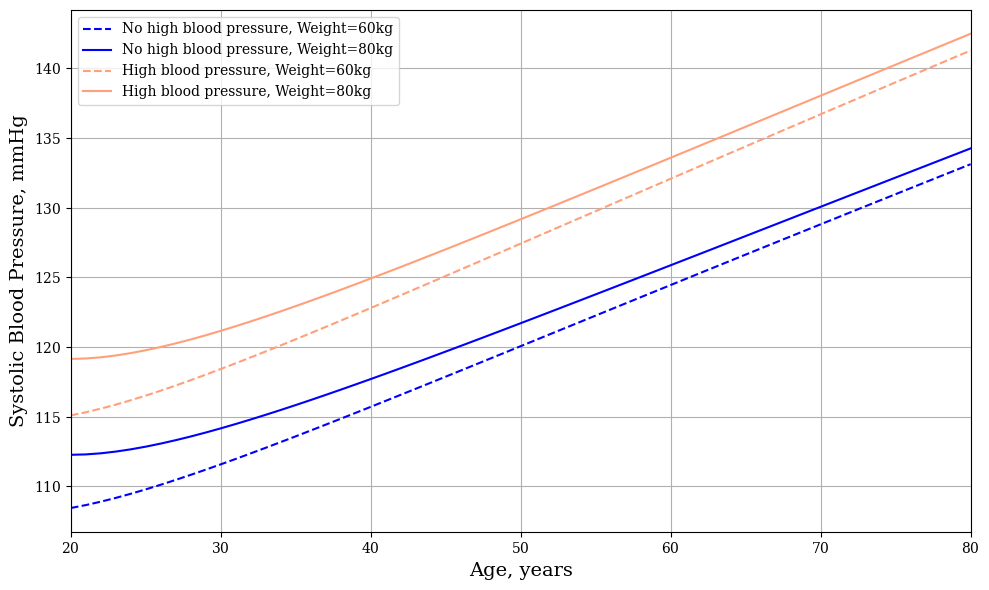

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# weight_values = [60, 70, 80]  # Reference values

# Define the range of ages (integer values only)
age_range = np.arange(20, 81, 1)

# Prepare the plot
plt.figure(figsize=(10, 6))

# Define cases using ONLY (weight, high_bp_diagnosis)
selected_cases = [
    (60, 0),  # 60kg, without high blood pressure
    (80, 0),  # 80kg, without high blood pressure
    (60, 1),  # 60kg, with high blood pressure
    (80, 1)   # 80kg, with high blood pressure
]

# Map (weight, high_bp_diagnosis) to (color, linestyle)
# Blue for normal BP, Red (lightsalmon) for high BP.
# Dashed for 60kg, solid for 80kg.
color_and_style = {
    (60, 0): ("blue", "--"),
    (80, 0): ("blue", "-"),
    (60, 1): ("lightsalmon", "--"),
    (80, 1): ("lightsalmon", "-")
}

# Loop through the simplified cases
for weight, high_sbp in selected_cases:
    color, linestyle = color_and_style[(weight, high_sbp)]

    # Compute SBP values
    sbp_values = [compute_SBP(Age=age, Weight=weight, high_bp_diagnosis=high_sbp) for age in age_range]

    if high_sbp == 1:
        label = f"High blood pressure, Weight={weight}kg"
    else:
        label = f"No high blood pressure, Weight={weight}kg"

    plt.plot(age_range, sbp_values, label=label, color=color, linestyle=linestyle)

# Set labels, title, and legend
plt.xlabel('Age, years', fontsize=14)
plt.ylabel('Systolic Blood Pressure, mmHg', fontsize=14)
# plt.title('Variation of SBP with Age', fontsize=16)
plt.legend(fontsize=10)
plt.xlim(20, 80)
plt.grid(True)
plt.tight_layout()
plt.savefig("results/Plots/imputation_models/SBP_variation.png", dpi=300)
plt.show()

In [ ]:
def SBP_sample(ind, post_samples_dict, seed):

  np.random.seed(seed)

  SBP_samples = post_samples_dict

  Age = ind['age']
  Weight = ind['weight']
  high_bp_diagnosis = ind['high_bp_diagnosis']

  SBP = np.exp((((((Weight / (SBP_samples['a2'] + (SBP_samples['a5'] * Age))) + SBP_samples['a1']) + np.sqrt(Age)) * SBP_samples['a7']) + (-(high_bp_diagnosis) * SBP_samples['a6'])))

  SBP += np.random.normal(loc=0, scale=post_samples_dict['sigma'])

  return SBP

In [ ]:
participant_dict = {1401589001: {'label': 'Female, age 64, smoker'},
                    1405300801: {'label': 'Female, age 64, non-smoker'},
                    1405615701: {'label': 'Female, age 64, high blood pressure'},

                    1400254901	: {'label': 'Female, age 31, smoker'},
                    1403819601: {'label': 'Female, age 33, non-smoker'},
                    1402383201: {'label': 'Female, age 38, high blood pressure'},
}

In [ ]:
participant_dict_sbp_test = {1400319101: {'label': 'Age 64, high blood pressure'},
                             1400288801: {'label': 'Age 64'},
                             1404720801: {'label': 'Age 32'},

}

In [ ]:
df_shes[(df_shes['age']==32) & (df_shes['high_bp_diagnosis']==0)]

In [ ]:
!ls data/posterior_samples/

 hdl_chol_posterior_nhanes_030826.nc   sbp_posterior_nhanes_08032926.nc
 height_posterior_shes_09032026.nc     totchol_nhanes_posterior_060326.nc
'old posteriors'		       weight_posterior_shes_09032026.nc


In [ ]:
def ind_variation_hist_SBP(df: pd.DataFrame, number_samples:int, participant_dict: dict, plot_name: str):

  inference_data = az.from_netcdf('data/posterior_samples/sbp_posterior_nhanes_08032926.nc')
  params = list(inference_data.posterior.keys())
  num_chains = len(inference_data.posterior[params[0]])
  num_samples = len(inference_data.posterior[params[0]][0])

  variable_samples_dict = {id: [] for id in participant_dict.keys()}

  for id in participant_dict.keys():
    ind = df.loc[id, :]

    for i in range(number_samples):
      np.random.seed(i)
      chain_sample = np.random.randint(1, num_chains)
      sample = np.random.randint(num_samples)

      post_samples_dict = {}
      for param_name in inference_data.posterior.data_vars:
          post_samples_dict[param_name] = float(
            inference_data.posterior[param_name][chain_sample][sample])

      sample = SBP_sample(ind=ind, post_samples_dict=post_samples_dict, seed=i)
      variable_samples_dict[id].append(sample)

  #colors = ["#332288", "#117733", "#44AA99","#CC6677"]
  colors = ["#006CD1", "#E8601C", "#40B0A6", "#FFD580", "#994F00", "#88CCEE", "#555555"]

  plt.figure(figsize=(12, 8))

  count=0
  for id in participant_dict.keys():
    sns.kdeplot(variable_samples_dict[id], label=participant_dict[id]['label'], fill=True, alpha=0.2, color= colors[count])
    count+=1

  plt.legend(fontsize=10)
  plt.xlabel("Systolic blood pressure, mmHg", fontsize=18)
  plt.ylabel("Probability density", fontsize=18)
  plt.savefig(f'results/Plots/imputation_models/{plot_name}.png', dpi=300)

  plt.show()

  return


In [ ]:
df_shes = pd.read_parquet('data/df_SHeS_unimputed.parquet')

In [ ]:
df_shes.rename(columns={ 'High BP': 'high_bp_diagnosis'}, inplace=True)

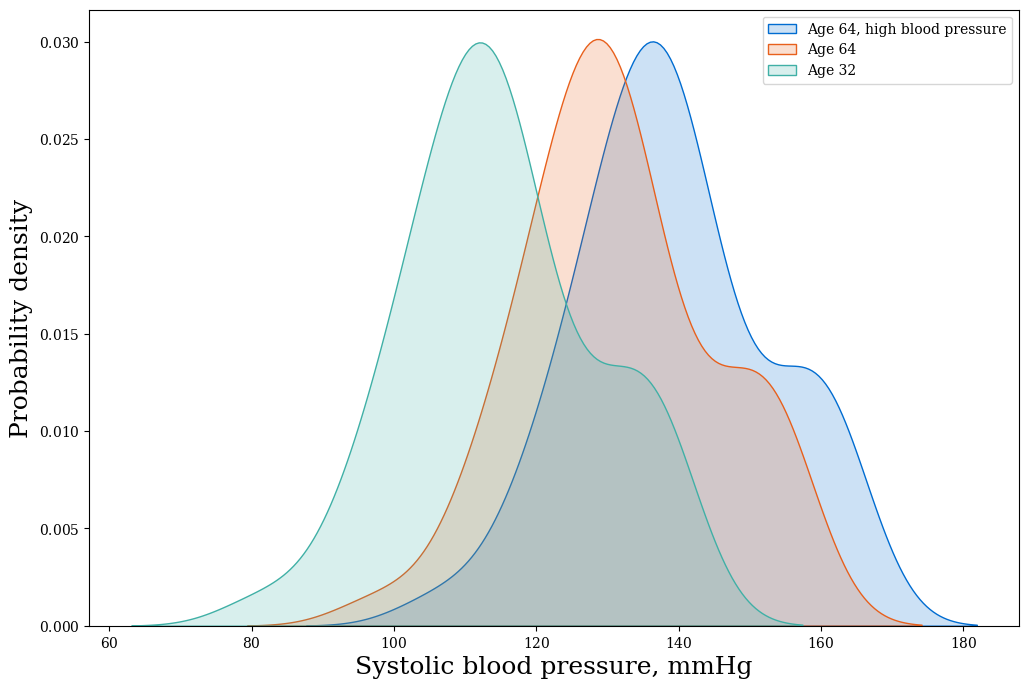

In [ ]:
ind_variation_hist_SBP(df=df_shes, number_samples=50, participant_dict=participant_dict_sbp_test, plot_name = 'sbp_variation_figureS11')

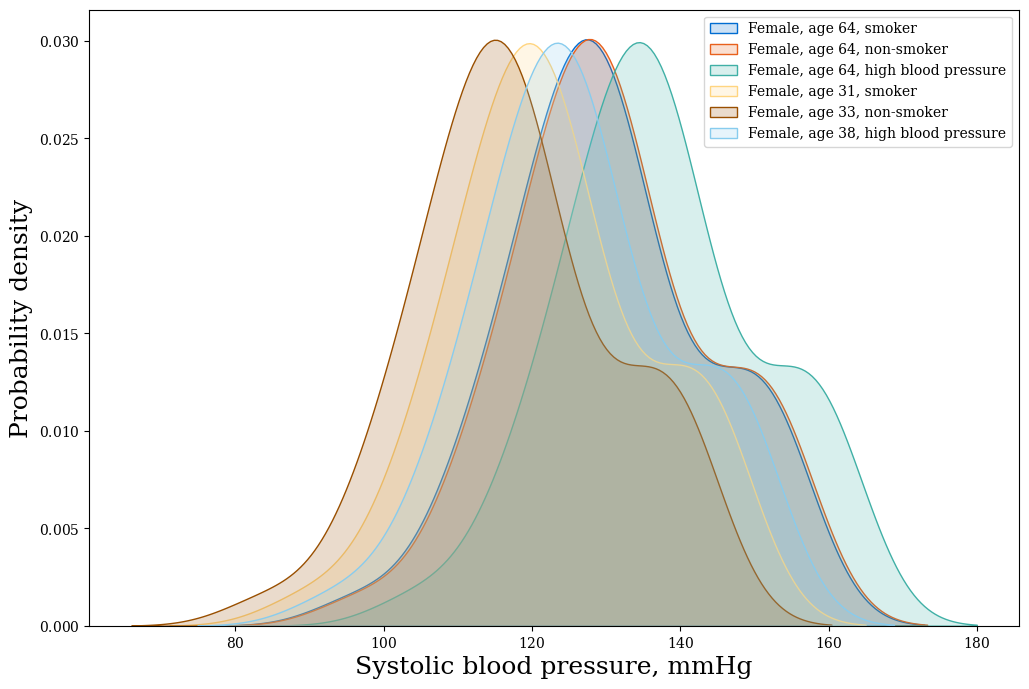

In [ ]:
ind_variation_hist_SBP(df=df_shes, number_samples=50, participant_dict=participant_dict)

In [ ]:
def hdl_sample(ind: pd.Series, post_samples_dict:dict, seed:int):

  np.random.seed(seed)

  Sex = ind['Sex']
  Age = ind['age']
  Weight = ind['weight']
  Height =  ind['height']
  BMI =  ind['BMI']
  Smoker = ind['Current Smoker']
  Diabetes = ind['Diabetes']

  hdl = (((((((post_samples_dict['a2'] ** (np.exp(BMI) ** post_samples_dict['a12'])) / -(post_samples_dict['a0'])) * (-(post_samples_dict['a0']) ** Sex)) + (post_samples_dict['a4'] ** Age)) * post_samples_dict['a2']) ** ((post_samples_dict['a8'] ** Diabetes) * post_samples_dict['a12'])) + -((post_samples_dict['a5']+ Smoker)))
  hdl += np.random.normal(loc=0, scale=post_samples_dict['sigma'])

  return hdl

def ind_variation_hist_hdl(df: pd.DataFrame, number_samples:int, participant_dict: dict):

  inference_data = az.from_netcdf('data/posterior_samples/hdl_chol_posterior_nhanes_030826.nc')
  params = list(inference_data.posterior.keys())
  num_chains = len(inference_data.posterior[params[0]])
  num_samples = len(inference_data.posterior[params[0]][0])

  variable_samples_dict = {id: [] for id in participant_dict.keys()}

  for id in participant_dict.keys():
    ind = df.loc[id, :]

    for i in range(number_samples):
      np.random.seed(i)
      chain_sample = np.random.randint(1, num_chains)
      sample = np.random.randint(num_samples)

      post_samples_dict = {}
      for param_name in inference_data.posterior.data_vars:
          post_samples_dict[param_name] = float(
            inference_data.posterior[param_name][chain_sample][sample])

      sample = hdl_sample(ind=ind, post_samples_dict=post_samples_dict, seed=i)
      variable_samples_dict[id].append(sample)

  #colors = ["#332288", "#117733", "#44AA99","#CC6677"]
  colors = ["#006CD1", "#E8601C", "#40B0A6", "#FFD580", "#994F00", "#88CCEE", "#555555"]

  plt.figure(figsize=(12, 8))

  count=0
  for id in participant_dict.keys():
    sns.kdeplot(variable_samples_dict[id], label=participant_dict[id]['label'], fill=True, alpha=0.2, color= colors[count])
    count+=1

  plt.legend(fontsize=10)
  plt.xlabel("HDL cholesterol, mg/dL", fontsize=18)
  plt.ylabel("Probability density", fontsize=18)
  plt.savefig('results/Plots/imputation_models/HDL_individual_variation_resubmission.png', dpi=300)

  plt.show()

  return

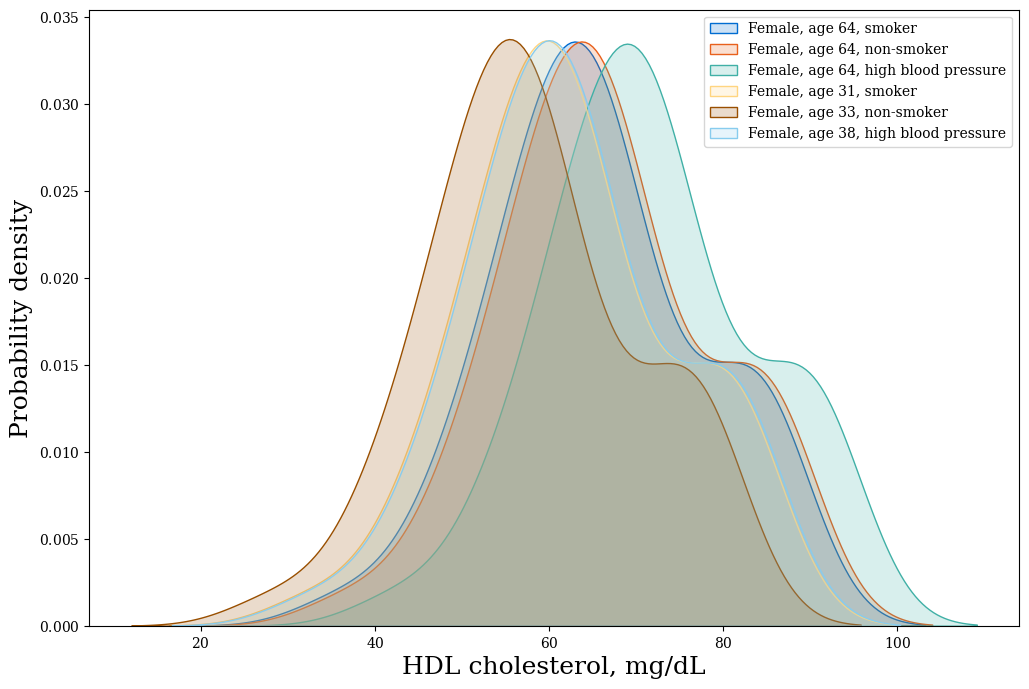

In [ ]:
ind_variation_hist_hdl(df=df_shes, number_samples=50, participant_dict=participant_dict)

In [ ]:
!ls data/posterior_samples/

 hdl_chol_posterior_nhanes_030826.nc   sbp_posterior_nhanes_08032926.nc
 height_posterior_shes_09032026.nc     totchol_nhanes_posterior_060326.nc
'old posteriors'		       weight_posterior_shes_09032026.nc


In [ ]:
def tot_chol_sample(ind: pd.Series,
                    tc_samples: dict,
                    hdl_samples: dict,
                    sbp_samples: dict,
                    seed: int):

  np.random.seed(seed)

  Sex = ind['Sex']
  Age = ind['age']
  Weight = ind['weight']
  Height =  ind['height']
  BMI =  ind['BMI']
  Smoker = ind['Current Smoker']
  Diabetes = ind['Diabetes']
  medication_high_BP = ind['Taking BPM']

  SBP = SBP_sample(ind=ind, post_samples_dict=sbp_samples, seed=seed)
  HDL_Cholesterol = hdl_sample(ind=ind, post_samples_dict=hdl_samples, seed=seed)

  TC = ((((((tc_samples['a12'] + ((tc_samples['a7'] ** Sex) + tc_samples['a10'])) * (((medication_high_BP + (Diabetes ** tc_samples['a3'])) / tc_samples['a2']) * tc_samples['a7'])) + tc_samples['a0']) / Age) ** (tc_samples['a4'] + ((Age * tc_samples['a10']) * ((tc_samples['a3'] * (medication_high_BP + SBP)) ** (tc_samples['a12'] * (tc_samples['a6'] + HDL_Cholesterol)))))) * tc_samples['a8'])

  return TC

In [ ]:
!ls data/posterior_samples/

 hdl_chol_posterior_nhanes_030826.nc   sbp_posterior_nhanes_08032926.nc
 height_posterior_shes_09032026.nc     totchol_nhanes_posterior_060326.nc
'old posteriors'		       weight_posterior_shes_09032026.nc


In [ ]:
def total_chol_histogram(df: pd.DataFrame, participant_dict: dict, number_samples: int):

  inference_hdl = az.from_netcdf('data/posterior_samples/hdl_chol_posterior_nhanes_030826.nc')
  inference_sbp = az.from_netcdf('data/posterior_samples/sbp_posterior_nhanes_08032926.nc')
  inference_tc = az.from_netcdf('data/posterior_samples/totchol_nhanes_posterior_060326.nc')

  inference_data = {"sbp": inference_sbp,
                    "hdl": inference_hdl,
                    "tc": inference_tc}

  # initialise the output dictionary
  chol_samples = {id: [] for id in participant_dict.keys()}
  participant_ids = list(participant_dict.keys())

  for id in participant_ids:
    ind = df.loc[id, :]

    for i in range(number_samples):
      np.random.seed(i)
      post_samples_dict = {"sbp": {}, "hdl": {}, "tc": {}}

      for variable in post_samples_dict.keys():
        # Extract the inference data for each imputation variabe
        variable_inference_data = inference_data[variable]
        params = list(variable_inference_data.posterior.keys())
        num_chains = len(variable_inference_data.posterior[params[0]])
        num_samples = len(variable_inference_data.posterior[params[0]][0])

        # randomly select a sample from the posterior parameter distributions
        chain_sample = np.random.randint(1, num_chains)
        sample = np.random.randint(num_samples)

        # Assign posterior sample values for each of the parameters for the same random seed
        for param_name in variable_inference_data.posterior.data_vars:
          post_samples_dict[variable][param_name] = float(variable_inference_data.posterior[param_name][chain_sample][sample])

        if ind['Diabetes'] == 1:
          with_diabetes = True
        else:
          with_diabetes = False

      systolic_blood_pressure = SBP_sample(ind=ind, post_samples_dict = post_samples_dict['sbp'], seed=i)
      HDL_cholesterol = hdl_sample(ind=ind, post_samples_dict = post_samples_dict['hdl'], seed=i)
      tot_cholesterol = tot_chol_sample(ind=ind, tc_samples=post_samples_dict['tc'], hdl_samples=post_samples_dict['hdl'], sbp_samples=post_samples_dict['sbp'], seed=i)
      chol_samples[id].append(tot_cholesterol)


  ############################ Plots ####################################

  #colors = ["#332288", "#117733", "#44AA99","#CC6677"]
  colors = ["#006CD1", "#E8601C", "#40B0A6", "#FFD580", "#994F00", "#88CCEE", "#555555"]

  plt.figure(figsize=(12, 8))

  count=0
  for id in participant_dict.keys():
    sns.kdeplot(chol_samples[id], label=participant_dict[id]['label'], fill=True, alpha=0.2, color= colors[count])
    count+=1

  plt.legend(fontsize=10)
  plt.xlabel("Total cholesterol, mg/dL", fontsize=18)
  plt.ylabel("Probability density", fontsize=18)
  plt.savefig('results/Plots/imputation_models/total_chol_individual_variation_resubmission.png', dpi=300)

  plt.show()

  return

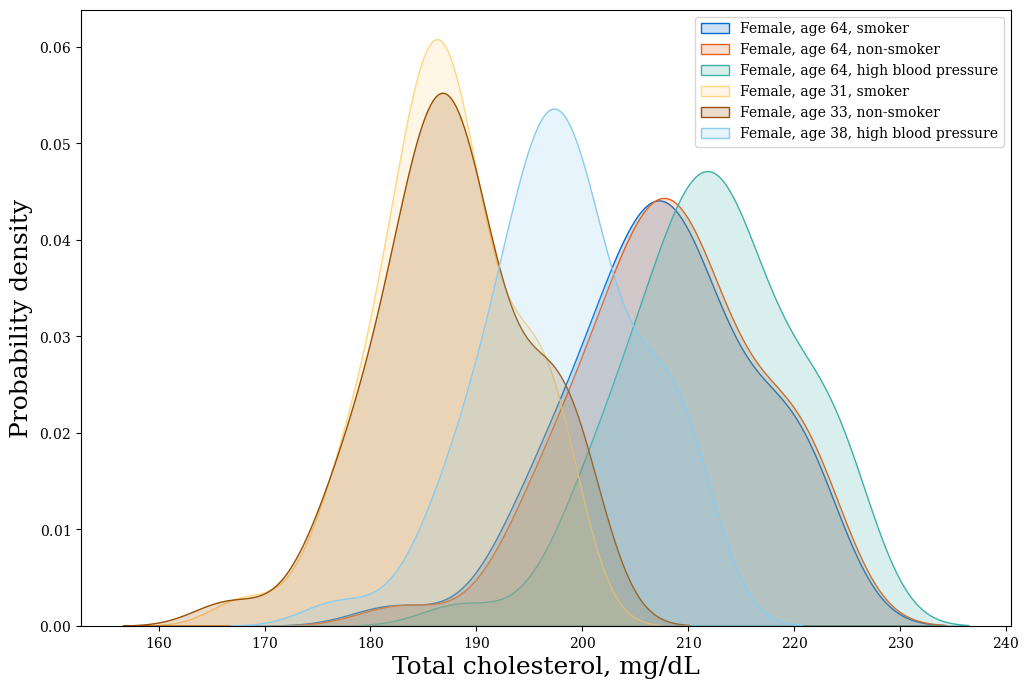

In [ ]:
total_chol_histogram(df=df_shes, participant_dict = participant_dict, number_samples = 50)

In [ ]:
def updated_Framingham_CVD_risk(row:pd.Series, with_diabetes: bool, seed: int, post_samples_dict:dict):

    """

    :param row: individual participant crresponding to a row in the dataframe
    :param with_diabetes: If True, calculates CVD risk assuming that the individual has diabetes. If False, calculates CVD risk assuming the individual does not have diabetes.
    :return: Estimated yearly CVD risk
    """

    CVD_Framingham_coeff_2008_update = {
    0: {
        'age': 3.06117,
        'TC': 1.12370,
        'HDL': -0.93263,
        'SBP_treated': 1.99881,
        'SBP_untreated': 1.93303,
        'Diabetes': 0.57367,
        'Smoker': 0.65451,
        'Baseline': 0.88936
    }
    ,
    1: {'age': 2.32888,
        'TC': 1.20904,
        'HDL': -0.70833,
        'SBP_treated': 2.82263,
        'SBP_untreated': 2.76157,
        'Diabetes': 0.69154,
        'Smoker': 0.52873,
        'Baseline': 0.95012
        }
}

    age = row['age']
    sex = row['Sex']
    taking_blood_pressure_medication = row['Taking BPM']
    smoker = row['Current Smoker']

    sbp_samples = post_samples_dict['sbp']
    hdl_samples = post_samples_dict['hdl']
    tc_samples = post_samples_dict['tc']

    systolic_blood_pressure = SBP_sample(ind=row, post_samples_dict = sbp_samples, seed=seed)
    HDL_cholesterol = hdl_sample(ind=row, post_samples_dict = hdl_samples, seed=seed)
    tot_cholesterol = tot_chol_sample(ind=row, tc_samples=tc_samples, hdl_samples=hdl_samples, sbp_samples=sbp_samples, seed=seed)


    if with_diabetes:
        diabetes = 1
    else:
        diabetes = row['Diabetes']

    CVD_dict = CVD_Framingham_coeff_2008_update[sex]

    S = 0
    S += np.log(age) * CVD_dict['age']
    S += np.log(tot_cholesterol) * CVD_dict['TC']
    S += np.log(HDL_cholesterol) * CVD_dict['HDL']

    if taking_blood_pressure_medication == 1:
        S += np.log(systolic_blood_pressure) * CVD_dict['SBP_treated']
    else:
        S += np.log(systolic_blood_pressure) * CVD_dict['SBP_untreated']


    if diabetes:
        S += CVD_dict['Diabetes']

    if smoker == 1:
        S += CVD_dict['Smoker']

    if sex == 1:
        CVD_risk_10yr = 1 - 0.95012 ** (np.exp(S - 26.1931))
    elif sex == 0:
        CVD_risk_10yr = 1 - 0.88936 ** (np.exp(S - 23.9802))

    if CVD_risk_10yr >= 1:
        print(age, sex, tot_cholesterol, HDL_cholesterol, systolic_blood_pressure, smoker)

    CVD_rate = -np.log(1 - CVD_risk_10yr) / 10  ## Transform the 10 year risk from Yadlowsky to a one year risk
    CVD_risk = 1 - np.exp(-CVD_rate)

    return CVD_risk

In [ ]:
!ls data/posterior_samples/

 hdl_chol_posterior_nhanes_030826.nc   sbp_posterior_nhanes_08032926.nc
 height_posterior_shes_09032026.nc     totchol_nhanes_posterior_060326.nc
'old posteriors'		       weight_posterior_shes_09032026.nc


In [ ]:
inference_hdl = az.from_netcdf('data/posterior_samples/hdl_chol_posterior_nhanes_030826.nc')
inference_sbp = az.from_netcdf('data/posterior_samples/sbp_posterior_nhanes_08032926.nc')
inference_tc = az.from_netcdf('data/posterior_samples/totchol_nhanes_posterior_060326.nc')
inference_data = {"sbp": inference_sbp,
                  "hdl": inference_hdl,
                  "tc": inference_tc}


In [ ]:
def CVD_risk_samples(df: pd.DataFrame, participant_dict: list, number_samples: int, inference_data: dict):

  # initialise the output dictionary
  CVD_risk_samples = {id: [] for id in participant_dict.keys()}
  participant_ids = list(participant_dict.keys())

  for id in participant_ids:
    ind = df.loc[id, :]

    for i in range(number_samples):
      np.random.seed(i)
      post_samples_dict = {"sbp": {}, "hdl": {}, "tc": {}}
      for variable in post_samples_dict.keys():
        # Extract the inference data for each imputation variabe
        variable_inference_data = inference_data[variable]
        params = list(variable_inference_data.posterior.keys())
        num_chains = len(variable_inference_data.posterior[params[0]])
        num_samples = len(variable_inference_data.posterior[params[0]][0])

        # randomly select a sample from the posterior parameter distributions
        chain_sample = np.random.randint(1, num_chains)
        sample = np.random.randint(num_samples)

        # Assign posterior sample values for each of the parameters for the same random seed
        for param_name in variable_inference_data.posterior.data_vars:
          post_samples_dict[variable][param_name] = float(variable_inference_data.posterior[param_name][chain_sample][sample])

        if ind['Diabetes'] == 1:
          with_diabetes = True
        else:
          with_diabetes = False

      # Once all of the posterior parameter values are sampledfor each imputation variable compute the associated CVD risk
      CVD_risk = updated_Framingham_CVD_risk(row = ind,
                                              with_diabetes=with_diabetes,
                                              seed=i,
                                              post_samples_dict = post_samples_dict)

      CVD_risk_samples[id].append(CVD_risk)

  return CVD_risk_samples, post_samples_dict

In [ ]:
def risk_histogram(risk_samples: dict, df: pd.DataFrame, participant_dict: dict):

  #colors = ["#332288", "#117733", "#44AA99","#CC6677", "#88CCEE","#DDCC77", "#999933"]
  colors = ["#006CD1", "#E8601C", "#40B0A6", "#FFD580", "#994F00", "#88CCEE", "#555555"]

  plt.figure(figsize=(12, 8))

  count = 0
  for id, risk_values in risk_samples.items():
    ind = df.loc[id, :]
    sns.kdeplot(risk_samples[id], label=participant_dict[id]['label'], fill=True, alpha=0.2, color= colors[count])
    count += 1

  plt.legend(fontsize=10)
  plt.xlabel("Yearly baseline CVD risk", fontsize=18)
  plt.ylabel("Probability density", fontsize=18)

  plt.savefig('results/Plots/imputation_models/CVD_risk_variation.png', dpi=300)

  plt.show()

  return


In [ ]:
cvd_risk_samples, post_samples_dict = CVD_risk_samples(df = df_shes,
                                    participant_dict = participant_dict,
                                    number_samples=50,
                                    inference_data=inference_data)



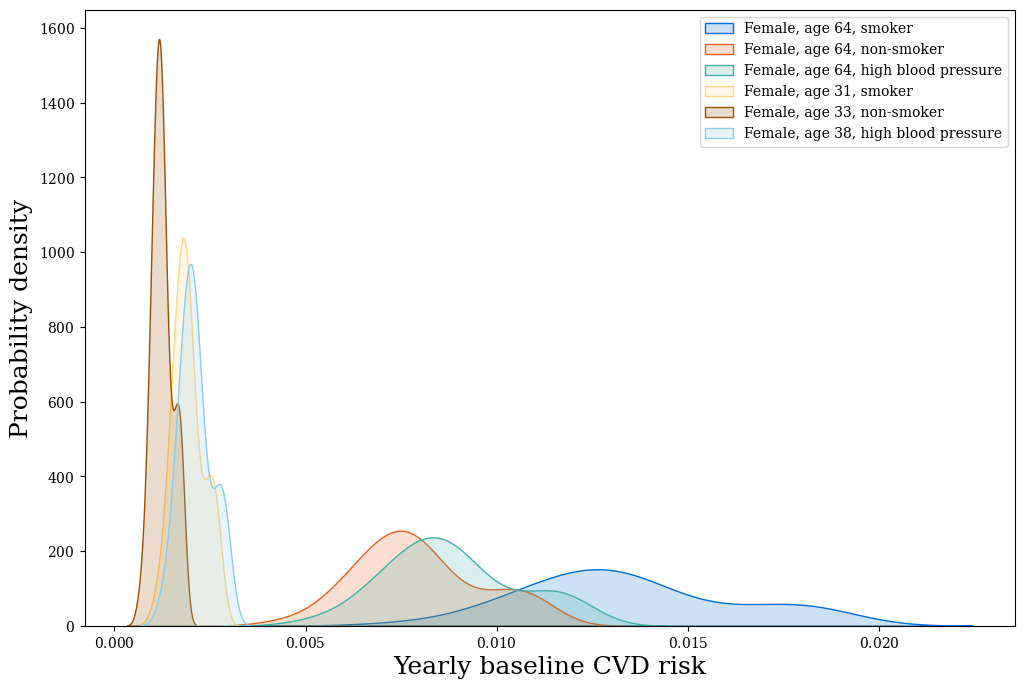

In [ ]:
risk_histogram(risk_samples = cvd_risk_samples, df=df_shes, participant_dict = participant_dict)